# LEHD LODES and Census Block Distance Analysis — Aggregated to Tracts

**Question**: What does the LEHD LODES data tell us wrt implied distance from worker to workplace over time? (Underying assumption is that remote work bay color these OD relationships), but there could be other reasons related to the administrative coding of multi-establishment jobs to firm headquarters, for example, and thus reflect a possible change in firm geography rather than actual worker-firm relationships.
**Approach**: We aggregate LODES OD flows from blocks to census tracts before computing distances.

- CA has ~9,000 tracts vs 519,000 blocks in the 2020 vintage
- We aggregate LODES to tract level resolution for tractability (trivial, from 15 digit block geoids, where the first 11 define tracts) 
- We tabulate the tract level OD - and then calculate distances for actually occurring cells as opposed to the brute force method covering the full 81M cell matrix
- Distances computed only for non-zero OD tract pairs via vectorized great-circle / Haversine distances on only the actually occurring cells (no full matrix)
- We bin the distances for each OD cell for easy summarization
- We look at commuters by distance band over time, along with concentrations of employment endpoints as indications of rising HQ encoding. We don't find clear evidence of the latter, though we do find increases in OD pairs more than 500km.


In [1]:
import pathlib
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:
cog_regions = {
    # ABAG/MTC
    '06001': 'ABAG/MTC',   # Alameda
    '06013': 'ABAG/MTC',   # Contra Costa
    '06041': 'ABAG/MTC',   # Marin
    '06055': 'ABAG/MTC',   # Napa
    '06075': 'ABAG/MTC',   # San Francisco
    '06081': 'ABAG/MTC',   # San Mateo
    '06085': 'ABAG/MTC',   # Santa Clara
    '06095': 'ABAG/MTC',   # Solano
    '06097': 'ABAG/MTC',   # Sonoma
    # SACOG
    '06017': 'SACOG',      # El Dorado
    '06061': 'SACOG',      # Placer
    '06067': 'SACOG',      # Sacramento
    '06101': 'SACOG',      # Sutter
    '06113': 'SACOG',      # Yolo
    '06115': 'SACOG',      # Yuba
    # SCAG
    '06025': 'SCAG',       # Imperial
    '06037': 'SCAG',       # Los Angeles
    '06059': 'SCAG',       # Orange
    '06065': 'SCAG',       # Riverside
    '06071': 'SCAG',       # San Bernardino
    '06111': 'SCAG',       # Ventura
    # Other COGs
    '06047': 'MCAG',       # Merced
    '06053': 'AMBAG',      # Monterey
    '06069': 'AMBAG',      # San Benito
    '06087': 'AMBAG',      # Santa Cruz
    '06077': 'SJCOG',      # San Joaquin
    '06099': 'STANCOG',    # Stanislaus
    '06073': 'SANDAG',     # San Diego    
    # Other
    '06033': 'Rest of CA', # Lake
    '06045': 'Mendocino CAG',
}


In [3]:
M_DRIVE = pathlib.Path('/Volumes/Data/Models') if os.name != 'nt' else pathlib.Path('M:/')


In [4]:
ca_fips_path = M_DRIVE / 'Crosswalks/geo/st06_ca_cou2020.txt'
ca_county_fips = pd.read_csv(ca_fips_path,sep='|',dtype=str)
ca_county_fips['STCOUNTY'] = ca_county_fips.STATEFP + ca_county_fips.COUNTYFP
ca_county_fips['county_name'] = ca_county_fips.COUNTYNAME#.str.replace(' County','')
ca_county_fips_map= ca_county_fips.set_index('STCOUNTY').county_name
ca_county_fips_map

STCOUNTY
06001            Alameda County
06003             Alpine County
06005             Amador County
06007              Butte County
06009          Calaveras County
06011             Colusa County
06013       Contra Costa County
06015          Del Norte County
06017          El Dorado County
06019             Fresno County
06021              Glenn County
06023           Humboldt County
06025           Imperial County
06027               Inyo County
06029               Kern County
06031              Kings County
06033               Lake County
06035             Lassen County
06037        Los Angeles County
06039             Madera County
06041              Marin County
06043           Mariposa County
06045          Mendocino County
06047             Merced County
06049              Modoc County
06051               Mono County
06053           Monterey County
06055               Napa County
06057             Nevada County
06059             Orange County
06061             Placer County

## Step 1b — National tract centroids from TIGER2024

LODES aux file includes workers living in other states, so we commensurately need centroids for all US tracts.  
Seems we don't have a full set on the M-drive (nor would we typically need this :))
TIGER packages tracts by state, so we download all 50 states + DC and merge.  
Files are cached to disk — re-running skips already-downloaded zips.

URL pattern: `https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_{ss}_tract.zip`


In [5]:
# For first time run, then we cache for later use, storing on M
# Kept the code here for mostly historical reasons 

import urllib.request

TRACT_CACHE = M_DRIVE / 'Data/GIS layers/Census/tracts/TIGER2024'
TRACT_CACHE.mkdir(parents=True, exist_ok=True)

# All 50 states + DC (no territories — LODES only covers the 50 states + DC)
STATE_FIPS = [
    '01','02','04','05','06','08','09','10','11','12','13','15','16','17','18','19',
    '20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35',
    '36','37','38','39','40','41','42','44','45','46','47','48','49','50','51','53',
    '54','55','56',
]
BASE_URL = 'https://www2.census.gov/geo/tiger/TIGER2024/TRACT'

for ss in STATE_FIPS:
    fname      = f'tl_2024_{ss}_tract.zip'
    cache_path = TRACT_CACHE / fname
    if cache_path.exists():
        print(f'  {fname} (cached)')
    else:
        url = f'{BASE_URL}/{fname}'
        print(f'  Downloading {fname}…', end=' ', flush=True)
        urllib.request.urlretrieve(url, cache_path)
        print('done')

print(f'\nAll {len(STATE_FIPS)} state tract zips present in {TRACT_CACHE}')


  tl_2024_01_tract.zip (cached)
  tl_2024_02_tract.zip (cached)
  tl_2024_04_tract.zip (cached)
  tl_2024_05_tract.zip (cached)
  tl_2024_06_tract.zip (cached)
  tl_2024_08_tract.zip (cached)
  tl_2024_09_tract.zip (cached)
  tl_2024_10_tract.zip (cached)
  tl_2024_11_tract.zip (cached)
  tl_2024_12_tract.zip (cached)
  tl_2024_13_tract.zip (cached)
  tl_2024_15_tract.zip (cached)
  tl_2024_16_tract.zip (cached)
  tl_2024_17_tract.zip (cached)
  tl_2024_18_tract.zip (cached)
  tl_2024_19_tract.zip (cached)
  tl_2024_20_tract.zip (cached)
  tl_2024_21_tract.zip (cached)
  tl_2024_22_tract.zip (cached)
  tl_2024_23_tract.zip (cached)
  tl_2024_24_tract.zip (cached)
  tl_2024_25_tract.zip (cached)
  tl_2024_26_tract.zip (cached)
  tl_2024_27_tract.zip (cached)
  tl_2024_28_tract.zip (cached)
  tl_2024_29_tract.zip (cached)
  tl_2024_30_tract.zip (cached)
  tl_2024_31_tract.zip (cached)
  tl_2024_32_tract.zip (cached)
  tl_2024_33_tract.zip (cached)
  tl_2024_34_tract.zip (cached)
  tl_202

In [6]:
# Centroid source toggle
# per state tiger files vs one national cartographic boundary file, *without* waterways.
# Gives more meaningful centroids. 

USE_CB500K = True   # flip to True to use the cartographic boundary file

CB500K_PATH = M_DRIVE / 'Data/GIS layers/Census/tracts/cb_2024_us_tract_500k'


In [7]:
# Build national tract centroid table — source determined by USE_CB500K toggle above

if USE_CB500K:
    print(f'Reading national CB 500k tract file from:\n  {CB500K_PATH}')
    gdf = gpd.read_file(CB500K_PATH).to_crs('EPSG:4326')
    pt  = gdf.representative_point()
    geoid_col = 'GEOID' if 'GEOID' in gdf.columns else gdf.filter(like='GEOID').columns[0]
    tract_centroids_national = pd.DataFrame({
        'tract_id': gdf[geoid_col].str.zfill(11),
        'lat': pt.y,
        'lon': pt.x,
    })
    print(f'National tract centroids (CB 500k): {len(tract_centroids_national):,} tracts')

else:
    print(f'Building centroids from {len(STATE_FIPS)} cached TIGER2024 state zips…')
    all_centroids = []
    for ss in STATE_FIPS:
        cache_path = TRACT_CACHE / f'tl_2024_{ss}_tract.zip'
        gdf = gpd.read_file(f'zip://{cache_path}').to_crs('EPSG:4326')
        pt  = gdf.representative_point()
        all_centroids.append(pd.DataFrame({
            'tract_id': gdf['GEOID'].str.zfill(11),
            'lat': pt.y,
            'lon': pt.x,
        }))
    tract_centroids_national = pd.concat(all_centroids, ignore_index=True)
    print(f'National tract centroids (TIGER):   {len(tract_centroids_national):,} tracts across {len(STATE_FIPS)} states')


Reading national CB 500k tract file from:
  M:\Data\GIS layers\Census\tracts\cb_2024_us_tract_500k
National tract centroids (CB 500k): 85,184 tracts


In [8]:
pd.options.display.float_format = '{:,.2f}'.format
# confirming geographic coords
tract_centroids_national.head()


,tract_id,lat,lon
0,06077005127,37.83,-121.28
1,06077003406,38.03,-121.30
2,06077004402,38.11,-121.26
3,06077005108,37.80,-121.22
4,06077000401,37.96,-121.31


## Set up Pipeline Functions

Encapsulates LODES loading -> tract aggregation -> distance join -> binning so any year can be processed with one call.


In [9]:
LODES_PATH = M_DRIVE / 'Data/Census/LEHD/RAW/lodes'

DIST_BINS   = [0, 5, 10, 25, 50, 100, 250, 500, 750, np.inf]
DIST_LABELS = ['<5 km', '5-10 km', '10-25 km', '25-50 km',
               '50-100 km', '100-250 km', '250-500 km', '500-750 km', '>1,000 km']

SOURCE_TEXT = 'Source: LEHD LODES Origin-Destination Employment Statistics, U.S. Census Bureau'

def _add_source(fig, text=SOURCE_TEXT):
    """Add a small source annotation to the bottom-left of *fig*."""
    fig.text(0.01, 0.01, text, fontsize=7, color='gray',
             ha='left', va='bottom', transform=fig.transFigure)


def load_lodes_tract_od(year, lodes_path=LODES_PATH, state='ca', job_type='JT00'):
    """Load LODES main+aux OD for *year*, aggregate to tract-pair level."""
    dfs = []
    for kind in ('main', 'aux'):
        f = lodes_path / f'{state}_od_{kind}_{job_type}_{year}.csv.gz'
        print(f'  {f.name}…', end=' ', flush=True)
        dfs.append(pd.read_csv(f, usecols=['h_geocode', 'w_geocode', 'S000', 'SI01', 'SI02', 'SI03'],
                               dtype={'h_geocode': str, 'w_geocode': str}))
        print(f'{len(dfs[-1]):,} rows')
    lodes = pd.concat(dfs, ignore_index=True)
    lodes['h_geocode'] = lodes['h_geocode'].str.strip().str.zfill(15)
    lodes['w_geocode'] = lodes['w_geocode'].str.strip().str.zfill(15)
    lodes['h_tract'] = lodes['h_geocode'].str[:11]
    lodes['w_tract'] = lodes['w_geocode'].str[:11]
    seg_cols = ['SI01', 'SI02', 'SI03']
    tract_od = lodes.groupby(['h_tract', 'w_tract'], as_index=False)[['S000'] + seg_cols].sum()
    tract_od['h_county'] = tract_od['h_tract'].str[:5]
    tract_od['w_county'] = tract_od['w_tract'].str[:5]
    tract_od['h_cog'] = tract_od['h_county'].map(cog_regions).fillna('Other/Out-of-CA')
    tract_od['w_cog'] = tract_od['w_county'].map(cog_regions).fillna('Other/Out-of-CA')
    print(f'  -> {len(tract_od):,} tract pairs  |  {tract_od["S000"].sum():,.0f} jobs  '
          f'(compressed {len(lodes)/len(tract_od):.0f}x)')
    return tract_od


import numpy as np

def _compute_od_distances(tract_od, tract_centroids_national):
    """
    Join centroids, compute Haversine distance in km, and apply 
    internal distance correction for intra-tract commutes.
    """
    # merge home (h) and work (w) centroids
    od = (
        tract_od
        .merge(tract_centroids_national.rename(columns={
            'tract_id': 'h_tract', 'lat': 'h_lat', 'lon': 'h_lon', 'area_sqkm': 'h_area'
        }), on='h_tract', how='left')
        .merge(tract_centroids_national.rename(columns={
            'tract_id': 'w_tract', 'lat': 'w_lat', 'lon': 'w_lon'
        }), on='w_tract', how='left')
    )

    # Check for missing centroids and log data loss
    n_missing = od[['h_lat', 'w_lat']].isna().any(axis=1).sum()
    if n_missing:
        lost = od.loc[od[['h_lat', 'w_lat']].isna().any(axis=1), 'S000'].sum()
        print(f'  Dropping {n_missing:,} pairs with no centroid ({lost:,.0f} jobs)')
    
    od = od.dropna(subset=['h_lat', 'h_lon', 'w_lat', 'w_lon'])
    
    # Convert decimal degrees to radians for spherical trigonometry
    rlat1, rlat2 = np.radians(od['h_lat'].values), np.radians(od['w_lat'].values)
    rlon1, rlon2 = np.radians(od['h_lon'].values), np.radians(od['w_lon'].values)
    
    # Calculate differences in coordinates
    dlat = rlat2 - rlat1
    dlon = rlon2 - rlon1

    # Haversine formula: calculate the square of half the chord length between points
    a = np.sin(dlat / 2)**2 + np.cos(rlat1) * np.cos(rlat2) * np.sin(dlon / 2)**2

    # Set constant for Earth's mean radius in kilometers
    R = 6371.0 
    
    # Compute great-circle distance in km
    od['dist_km'] = 2 * R * np.arcsin(np.sqrt(a))

    # Apply internal distance correction for same-tract origin/destination
    # Proxy: 0.376 * sqrt(Area) approximates average internal trip length
    mask_internal = od['h_tract'] == od['w_tract']
    if 'h_area' in od.columns:
        od.loc[mask_internal, 'dist_km'] = 0.376 * np.sqrt(od.loc[mask_internal, 'h_area'])
        
    return od

def _bin_summary(od, jobs_col='S000'):
    """Bin an od-with-dist_km DataFrame and return the standard summary table."""
    od = od.copy()
    od['dist_bin'] = pd.cut(od['dist_km'], bins=DIST_BINS, labels=DIST_LABELS, right=True)
    return (
        od.groupby('dist_bin', observed=False)[jobs_col]
        .agg(jobs='sum', od_pairs='count')
        .assign(
            jobs_pct   = lambda d: d['jobs']    / d['jobs'].sum(),
            pairs_pct  = lambda d: d['od_pairs'] / d['od_pairs'].sum(),
            jobs_cumul = lambda d: (d['jobs'] / d['jobs'].sum()).cumsum(),
        )
    )


def compute_distance_summary(tract_od, tract_centroids_national):
    return _bin_summary(_compute_od_distances(tract_od, tract_centroids_national))


def compute_geo_stats(od):
    """Return (cog_dist, county_dist) flow-weighted mean distance tables."""
    def _wmean(grp):
        w = grp['S000']
        return pd.Series({
            'mean_dist_km': np.average(grp['dist_km'], weights=w),
            'total_jobs':   int(w.sum()),
            'od_pairs':     len(grp),
        })
    cog_dist = (
        od.groupby(['h_cog', 'w_cog'])
        .apply(_wmean, include_groups=False)
        .reset_index()
    )
    intra = od[(od['h_cog'] == od['w_cog']) & (~od['h_cog'].str.startswith('Other'))].copy()
    county_dist = (
        intra.groupby(['h_cog', 'h_county', 'w_county'])
        .apply(_wmean, include_groups=False)
        .reset_index()
    )
    return cog_dist, county_dist


def _highlight_diagonal(ax, n, lw=1.5, color='black'):
    """Draw thick black rectangle borders on every diagonal cell of an n×n seaborn heatmap."""
    import matplotlib.patches as mpatches
    for i in range(n):
        ax.add_patch(mpatches.Rectangle(
            (i, i), 1, 1,
            fill=False, edgecolor=color, linewidth=lw, clip_on=False
        ))


def _nse(jobs_series):
    """Normalized Shannon Entropy of a job distribution across tracts.
    Returns 0 (all jobs in one tract) to 1 (perfectly even across all tracts)."""
    p = jobs_series / jobs_series.sum()
    p = p[p > 0]
    n = len(p)
    if n <= 1:
        return 0.0
    return float(-(p * np.log(p)).sum() / np.log(n))


def _county_label(fips):
    return ca_county_fips_map.get(fips, fips)


def _grid_shape(n):
    ncols = int(np.ceil(np.sqrt(n)))
    nrows = int(np.ceil(n / ncols))
    return nrows, ncols


def plot_od_scatter(years, facet_by='cog', cog_focus=None, county_cog='ABAG/MTC',
                    dist_km_max=800, cmap=None, gridsize=None, geo_end='work',
                    kind='hexbin', alpha=0.15, max_points=40_000):
    """OD distance (x) vs jobs (y) faceted by COG, county, or year.

    Parameters
    ----------
    years       : int or list[int]
    facet_by    : 'cog' | 'county' | 'year'
    cog_focus   : list of COG names; None = all CA COGs
    county_cog  : COG for facet_by='county'
    dist_km_max : clip x-axis (km)
    cmap        : colormap override
    gridsize    : hexbin gridsize override
    geo_end     : 'work' (default) or 'home'
    kind        : 'hexbin' (default) or 'scatter'
    alpha       : scatter transparency
    max_points  : scatter sample cap per panel
    """
    if isinstance(years, int):
        years = [years]
    _cmap     = cmap    or ('YlGnBu' if facet_by == 'county' else 'YlOrRd')
    _gridsize = gridsize or (40      if facet_by == 'county' else 25)
    cog_col    = 'w_cog'    if geo_end == 'work' else 'h_cog'
    county_col = 'w_county' if geo_end == 'work' else 'h_county'
    end_label  = 'workplace' if geo_end == 'work' else 'residence'

    def _draw_panel(ax, sub):
        if kind == 'scatter':
            if len(sub) > max_points:
                sub = sub.sample(max_points, random_state=42)
            pt_size = np.clip(np.log1p(sub['S000']) * 2, 1, 60) * 2
            ax.scatter(sub['dist_km'], sub['S000'],
                       s=pt_size, alpha=alpha,
                       color='steelblue', edgecolors='none', linewidths=0,
                       rasterized=True)
            ax.set_yscale('log')
        else:
            hb = ax.hexbin(sub['dist_km'], sub['S000'],
                           gridsize=_gridsize, bins='log', cmap=_cmap,
                           yscale='log', mincnt=1)
            ax.figure.colorbar(hb, ax=ax, label='# tract pairs in cell (log scale)')

    def _y_label():
        return 'Jobs per OD pair' if kind == 'scatter' else 'Jobs per OD pair (log)'

    def _subtitle(suptitle):
        if kind == 'scatter':
            return (f'{suptitle}\n'
                    f'Each dot = one tract-pair OD flow; size \u221d log(jobs). '
                    f'Panels >{max_points:,} pairs randomly sampled.')
        return (f'{suptitle}\ncolor = density of OD tract pairs in each hex cell (log scale) \u2014 '
                f'many low-volume pairs can dominate color without representing large employment')

    if facet_by == 'year':
        geo_filter = cog_focus or [county_cog]
        geo_label  = ', '.join(geo_filter) if len(geo_filter) <= 3 else f'{len(geo_filter)} COGs'
        suptitle   = f'OD distance vs jobs \u2014 {geo_label} ({end_label}) \u2014 across years'
        panels = list(years)
        nrows, ncols = _grid_shape(len(panels))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        axes_flat = axes.flatten()
        for ax, year in zip(axes_flat, panels):
            od_sc = ods[year].copy()
            od_sc = od_sc[(od_sc['dist_km'] <= dist_km_max) & (od_sc['S000'] > 0)]
            od_sc = od_sc[od_sc[cog_col].isin(geo_filter)]
            _draw_panel(ax, od_sc)
            ax.set_title(str(year), fontsize=10, fontweight='bold')
            ax.set_xlabel('OD distance (km)', fontsize=8)
            ax.set_ylabel(_y_label(), fontsize=8)
        for ax in axes_flat[len(panels):]:
            ax.set_visible(False)
        fig.suptitle(_subtitle(suptitle), y=1.01)
        plt.tight_layout()
        _add_source(fig)
        plt.show()
        return

    for year in years:
        od_sc = ods[year].copy()
        od_sc = od_sc[(od_sc['dist_km'] <= dist_km_max) & (od_sc['S000'] > 0)]
        if facet_by == 'cog':
            panels = [c for c in sorted(od_sc[cog_col].unique())
                      if 'Other' not in c and 'Out-of' not in c]
            if cog_focus:
                panels = [c for c in panels if c in cog_focus]
            col_key  = cog_col
            label_fn = lambda x: x
            suptitle = f'OD distance vs jobs \u2014 by {end_label} COG  ({year})'
        else:
            od_sc    = od_sc[od_sc[cog_col] == county_cog]
            panels   = sorted(od_sc[county_col].unique())
            col_key  = county_col
            label_fn = _county_label
            suptitle = f'OD distance vs jobs \u2014 by {end_label} county within {county_cog}  ({year})'
        if not panels:
            print(f'  No panels for year={year}, facet_by={facet_by!r}')
            continue
        nrows, ncols = _grid_shape(len(panels))
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                                 sharex=True, squeeze=False)
        axes_flat = axes.flatten()
        for ax, panel in zip(axes_flat, panels):
            sub = od_sc[od_sc[col_key] == panel]
            _draw_panel(ax, sub)
            ax.set_title(label_fn(panel), fontsize=10, fontweight='bold')
            ax.set_xlabel('OD distance (km)', fontsize=8)
            ax.set_ylabel(_y_label(), fontsize=8)
        for ax in axes_flat[len(panels):]:
            ax.set_visible(False)
        fig.suptitle(_subtitle(suptitle), fontweight='bold', y=1.01)
        plt.tight_layout()
        _add_source(fig)
        plt.show()


def plot_band_trend(ods, years=None, *,
                    h_cog=None, h_county=None,
                    w_cog=None, w_county=None,
                    label_end=True):
    """Indexed band-trend chart: each bin's job share relative to the base year."""
    if years is None:
        years = sorted(ods.keys())
    parts = []
    if h_cog:
        tag = ', '.join(h_cog) if len(h_cog) <= 3 else f'{len(h_cog)} COGs'
        parts.append(f'Home COG: {tag}')
    if h_county:
        names = [_county_label(f) for f in h_county]
        tag = ', '.join(names) if len(names) <= 3 else f'{len(names)} counties'
        parts.append(f'Home county: {tag}')
    if w_cog:
        tag = ', '.join(w_cog) if len(w_cog) <= 3 else f'{len(w_cog)} COGs'
        parts.append(f'Work COG: {tag}')
    if w_county:
        names = [_county_label(f) for f in w_county]
        tag = ', '.join(names) if len(names) <= 3 else f'{len(names)} counties'
        parts.append(f'Work county: {tag}')
    universe = '  |  '.join(parts) if parts else 'All CA jobs'
    local_summaries = {}
    for yr in years:
        sub = ods[yr]
        if h_cog    is not None: sub = sub[sub['h_cog'].isin(h_cog)]
        if h_county is not None: sub = sub[sub['h_county'].isin(h_county)]
        if w_cog    is not None: sub = sub[sub['w_cog'].isin(w_cog)]
        if w_county is not None: sub = sub[sub['w_county'].isin(w_county)]
        local_summaries[yr] = _bin_summary(sub)
    job_pct   = pd.concat(local_summaries, names=['year'])['jobs_pct'].unstack('year')
    base_year = years[0]
    relative  = job_pct.div(job_pct[base_year], axis=0).T
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_title(f'Job-share index by distance band  (base = {base_year})  \u2014  {universe}',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(f'Job share relative to {base_year}', fontsize=9)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_xticks(years)
    ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='_base')
    bin_colors = plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(DIST_LABELS)))
    last_yr   = years[-1]
    yr_span   = years[-1] - years[0]
    end_items = []
    for bin_label, color in zip(DIST_LABELS, bin_colors):
        y_vals = relative[bin_label]
        ax.plot(years, y_vals, marker='o', label=bin_label,
                color=color, linewidth=2, markersize=5)
        if label_end:
            end_items.append((float(y_vals[last_yr]),
                              float(job_pct.loc[bin_label, last_yr]) * 100,
                              color))
    if label_end and end_items:
        end_items.sort(key=lambda t: t[0])
        placed  = []
        min_gap = 0.06
        for y_line, raw_pct, color in end_items:
            y_text = y_line
            if placed and (y_text - placed[-1][1]) < min_gap:
                y_text = placed[-1][1] + min_gap
            placed.append((y_line, y_text, f'{raw_pct:.1f}%', color))
        ax.set_xlim(years[0] - yr_span * 0.02, last_yr + yr_span * 0.25)
        y_lo, y_hi = ax.get_ylim()
        top_edge = placed[-1][1] + min_gap
        if top_edge > y_hi:
            ax.set_ylim(y_lo, top_edge)
        x_dot   = last_yr + yr_span * 0.01
        x_label = last_yr + yr_span * 0.05
        for y_line, y_text, txt, color in placed:
            if abs(y_text - y_line) > 0.01:
                ax.plot([x_dot, x_label - yr_span * 0.005], [y_line, y_text],
                        color=color, linewidth=0.6, linestyle='-', alpha=0.6,
                        clip_on=False)
            ax.text(x_label, y_text, txt, fontsize=9, color=color,
                    va='center', ha='left', clip_on=False)
    ax.legend(title='Distance band', fontsize=8, title_fontsize=8,
              loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.tight_layout()
    _add_source(fig)
    plt.show()


def plot_distance_overview(ods, years=None, w_cog=None, w_county=None):
    """Grouped bar chart + cumulative curve of job share by distance bin.

    Parameters
    ----------
    ods      : dict {year: od DataFrame with dist_km, S000, w_cog, w_county}
    years    : list of years; defaults to sorted(ods.keys())
    w_cog    : list of workplace COG names to restrict to; None = all CA
    w_county : list of 5-digit workplace county FIPS; None = all CA
    """
    if years is None:
        years = sorted(ods.keys())
    parts = []
    if w_cog:
        tag = ', '.join(w_cog) if len(w_cog) <= 3 else f'{len(w_cog)} COGs'
        parts.append(f'Workplace COG: {tag}')
    if w_county:
        names = [_county_label(f) for f in w_county]
        tag = ', '.join(names) if len(names) <= 3 else f'{len(names)} counties'
        parts.append(f'Workplace county: {tag}')
    geo_label = '  |  '.join(parts) if parts else 'All CA'
    local_summaries = {}
    for yr in years:
        sub = ods[yr]
        if w_cog:    sub = sub[sub['w_cog'].isin(w_cog)]
        if w_county: sub = sub[sub['w_county'].isin(w_county)]
        local_summaries[yr] = _bin_summary(sub)
    colors    = plt.cm.Blues(np.linspace(0.4, 0.9, len(years)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    x     = np.arange(len(DIST_LABELS))
    n     = len(years)
    width = 0.8 / n
    for i, (year, color) in enumerate(zip(years, colors)):
        vals = local_summaries[year]['jobs_pct'].mul(100).to_numpy()
        axes[0].bar(x + (i - n/2 + 0.5) * width, vals, width=width,
                    label=str(year), color=color, edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(DIST_LABELS, rotation=40, ha='right', fontsize=8)
    axes[0].set_ylabel('% of total jobs')
    axes[0].set_title(f'Job share by OD distance \u2014 {geo_label}')
    axes[0].legend(title='Year', fontsize=8)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
    for year, color in zip(years, colors):
        local_summaries[year]['jobs_cumul'].mul(100).plot(
            ax=axes[1], marker='o', label=str(year), color=color)
    axes[1].set_xticks(range(len(DIST_LABELS)))
    axes[1].set_xticklabels(DIST_LABELS, rotation=40, ha='right', fontsize=8)
    axes[1].set_ylabel('Cumulative % of jobs')
    axes[1].set_title('Cumulative job share by distance')
    axes[1].axhline(90, color='gray', linestyle='--', linewidth=0.8, label='_nolegend_')
    axes[1].legend(title='Year', fontsize=8)
    plt.suptitle(f'Distance distribution \u2014 {geo_label}', fontweight='bold', y=1.01)
    plt.tight_layout()
    _add_source(fig)
    plt.show()


def plot_job_concentration(ods, years=None, w_cog=None, top_pcts=(10, 25, 50)):
    """Tract-level job concentration at the workplace end over time.

    Measures how evenly (or unevenly) jobs are distributed across workplace tracts.
    Rising concentration = fewer tracts capturing a growing share of jobs, consistent
    with either organic agglomeration or HQ-coding drift.

    Parameters
    ----------
    ods      : dict {year: od DataFrame with w_tract, w_cog, S000}
    years    : list of years; defaults to sorted(ods.keys())
    w_cog    : workplace COG name to restrict to (string, not list); None = all CA
    top_pcts : tuple of top-percentile thresholds to track (default 10, 25, 50)
    """
    if years is None:
        years = sorted(ods.keys())
    geo_label = f'Workplace COG: {w_cog}' if w_cog else 'All CA'
    rows = []
    tract_share_by_year = {}
    for yr in years:
        sub = ods[yr]
        if w_cog:
            sub = sub[sub['w_cog'] == w_cog]
        tract_jobs = sub.groupby('w_tract')['S000'].sum().sort_values(ascending=False)
        total    = tract_jobs.sum()
        n_tracts = len(tract_jobs)
        if total == 0 or n_tracts == 0:
            continue
        cum_share = tract_jobs.cumsum() / total
        row = {'year': yr, 'n_tracts': n_tracts, 'total_jobs': int(total)}
        for pct in top_pcts:
            k = max(1, int(np.ceil(n_tracts * pct / 100)))
            row[f'top{pct}pct'] = tract_jobs.iloc[:k].sum() / total * 100
        v   = tract_jobs.values[::-1].astype(float)
        idx = np.arange(1, len(v) + 1)
        row['gini'] = (2 * (idx * v).sum()) / (len(v) * v.sum()) - (len(v) + 1) / len(v)
        row['hhi']  = ((tract_jobs / total) ** 2).sum()
        row['nse']  = _nse(tract_jobs)
        rows.append(row)
        tract_share_by_year[yr] = cum_share.values
    if not rows:
        print('No data for plot_job_concentration')
        return
    conc = pd.DataFrame(rows).set_index('year')
    display_cols = ['n_tracts', 'total_jobs'] + [f'top{p}pct' for p in top_pcts] + ['gini', 'hhi', 'nse']
    pd.options.display.float_format = '{:.4f}'.format
    print(f'Workplace job concentration \u2014 {geo_label}\n')
    print(conc[display_cols].to_string())
    print()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    clrs = plt.cm.plasma(np.linspace(0.15, 0.85, len(top_pcts)))
    for pct, c in zip(top_pcts, clrs):
        axes[0].plot(conc.index, conc[f'top{pct}pct'],
                     marker='o', label=f'Top {pct}% of tracts', color=c, linewidth=2)
    axes[0].set_title(f'Share of jobs in top-N% of workplace tracts\n{geo_label}',
                      fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Cumulative job share (%)', fontsize=9)
    axes[0].set_xlabel('Year', fontsize=9)
    axes[0].set_xticks(years)
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', linewidth=0.4, alpha=0.5)
    yr_colors = {years[0]: 'steelblue', years[-1]: 'firebrick'}
    for yr in [years[0], years[-1]]:
        if yr not in tract_share_by_year:
            continue
        cs  = tract_share_by_year[yr]
        pct = np.arange(1, len(cs) + 1) / len(cs) * 100
        axes[1].plot(pct, cs * 100, label=str(yr), color=yr_colors[yr], linewidth=2)
    axes[1].plot([0, 100], [0, 100], color='gray', linewidth=0.8, linestyle='--', label='Equal')
    # Vertical reference lines at the same top-pct thresholds as the left panel
    for pct_val, c in zip(top_pcts, clrs):
        axes[1].axvline(pct_val, color=c, linewidth=2.5, linestyle=':', alpha=0.85)
        axes[1].text(pct_val + 0.8, 2, f'Top {pct_val}%', fontsize=7, color=c,
                     va='bottom', ha='left', rotation=90)
    axes[1].set_title(f'Lorenz curve \u2014 first vs last year\n{geo_label}',
                      fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Cumulative % of jobs', fontsize=9)
    axes[1].set_xlabel('Cumulative % of tracts (ranked by jobs, descending)', fontsize=9)
    axes[1].legend(fontsize=8)
    axes[1].grid(linewidth=0.3, alpha=0.4)
    plt.suptitle('Job concentration at workplace tract level', fontweight='bold', y=1.02)
    plt.tight_layout()
    _add_source(fig)
    plt.show()


SEG_LABELS = {
    'SI01': 'Goods-producing',
    'SI02': 'Trade & Transport',
    'SI03': 'Other Services',
}


def plot_band_trend_seg(ods, years=None, *,
                        h_cog=None, h_county=None,
                        w_cog=None, w_county=None,
                        label_end=True, seg_labels=None,
                        sharey=True):
    """Band-trend index chart faceted by industry segment — 1 x N_segs column grid.

    Each panel mirrors plot_band_trend for one industry segment, sharing a
    common y-axis so relative magnitudes are directly comparable across segments.
    Uses the SI01/SI02/SI03 columns present in each year's OD DataFrame.

    Parameters
    ----------
    ods        : dict {year: od DataFrame} — the same dict used everywhere else
    years      : list of years; defaults to sorted(ods.keys())
    h_cog / h_county / w_cog / w_county : same filter kwargs as plot_band_trend
    label_end  : annotate end-point job-share labels (default True)
    seg_labels : dict mapping seg_key -> display name; defaults to SEG_LABELS
    sharey     : share y-axis across all segment panels (default True).
                 Set to False to let each panel scale to its own data range.
    """
    segs = list(SEG_LABELS.keys())
    if years is None:
        years = sorted(ods.keys())
    if seg_labels is None:
        seg_labels = SEG_LABELS

    parts = []
    if h_cog:
        tag = ', '.join(h_cog) if len(h_cog) <= 3 else f'{len(h_cog)} COGs'
        parts.append(f'Home COG: {tag}')
    if h_county:
        names = [_county_label(f) for f in h_county]
        tag = ', '.join(names) if len(names) <= 3 else f'{len(names)} counties'
        parts.append(f'Home county: {tag}')
    if w_cog:
        tag = ', '.join(w_cog) if len(w_cog) <= 3 else f'{len(w_cog)} COGs'
        parts.append(f'Work COG: {tag}')
    if w_county:
        names = [_county_label(f) for f in w_county]
        tag = ', '.join(names) if len(names) <= 3 else f'{len(names)} counties'
        parts.append(f'Work county: {tag}')
    universe = '  |  '.join(parts) if parts else 'All CA jobs'

    base_year = years[0]
    last_yr   = years[-1]
    yr_span   = years[-1] - years[0]
    bin_colors = plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, len(DIST_LABELS)))

    fig, axes = plt.subplots(1, len(segs), figsize=(4 * len(segs), 5),
                             sharey=sharey, squeeze=False)

    for ax, seg in zip(axes[0], segs):
        local_summaries = {}
        for yr in years:
            sub = ods[yr]
            if h_cog    is not None: sub = sub[sub['h_cog'].isin(h_cog)]
            if h_county is not None: sub = sub[sub['h_county'].isin(h_county)]
            if w_cog    is not None: sub = sub[sub['w_cog'].isin(w_cog)]
            if w_county is not None: sub = sub[sub['w_county'].isin(w_county)]
            local_summaries[yr] = _bin_summary(sub, jobs_col=seg)

        job_pct  = pd.concat(local_summaries, names=['year'])['jobs_pct'].unstack('year')
        relative = job_pct.div(job_pct[base_year], axis=0).T

        end_items = []
        for bin_label, color in zip(DIST_LABELS, bin_colors):
            y_vals = relative[bin_label]
            ax.plot(years, y_vals, marker='o', color=color, linewidth=2, markersize=4)
            if label_end:
                end_items.append((float(y_vals[last_yr]),
                                  float(job_pct.loc[bin_label, last_yr]) * 100,
                                  color))

        ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(seg_labels.get(seg, seg), fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_xticks(years)

        if label_end and end_items:
            end_items.sort(key=lambda t: t[0])
            placed  = []
            min_gap = 0.06
            for y_line, raw_pct, color in end_items:
                y_text = y_line
                if placed and (y_text - placed[-1][1]) < min_gap:
                    y_text = placed[-1][1] + min_gap
                placed.append((y_line, y_text, f'{raw_pct:.1f}%', color))
            ax.set_xlim(years[0] - yr_span * 0.02, last_yr + yr_span * 0.30)
            y_lo, y_hi = ax.get_ylim()
            top_edge = placed[-1][1] + min_gap
            if top_edge > y_hi:
                ax.set_ylim(y_lo, top_edge)
            x_dot   = last_yr + yr_span * 0.01
            x_label = last_yr + yr_span * 0.06
            for y_line, y_text, txt, color in placed:
                if abs(y_text - y_line) > 0.01:
                    ax.plot([x_dot, x_label - yr_span * 0.005], [y_line, y_text],
                            color=color, linewidth=0.6, linestyle='-', alpha=0.6,
                            clip_on=False)
                ax.text(x_label, y_text, txt, fontsize=8, color=color,
                        va='center', ha='left', clip_on=False)

    axes[0][0].set_ylabel(f'Job share relative to {base_year}', fontsize=9)

    # legend on rightmost panel — shares bin colors with all panels
    handles = [plt.Line2D([0], [0], color=c, linewidth=2, marker='o', markersize=4)
               for c in bin_colors]
    axes[0][-1].legend(handles, DIST_LABELS,
                       title='Distance band', fontsize=7, title_fontsize=7,
                       loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

    fig.suptitle(
        f'Job-share index by distance band — by industry segment'
        f'(base = {base_year})  —  {universe}',
        fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    _add_source(fig)
    plt.show()



print('Pipeline functions defined.')


Pipeline functions defined.


## Multi-Year Run

This is just the thin call - we run with several years to get a bit of spread. Each year takes about a minute to load and process on a decent mac.


In [10]:
%%time
YEARS = [2011, 2014, 2017, 2020, 2023]

summaries = {}   # {year: binned summary DataFrame}
geo_stats = {}   # {year: (cog_dist, county_dist)}
ods       = {}   # {year: full od DataFrame with dist_km — for scatter analysis}

for year in YEARS:
    print(f'\n{year} ')
    tract_od = load_lodes_tract_od(year)
    od       = _compute_od_distances(tract_od, tract_centroids_national)
    summaries[year] = _bin_summary(od) # summarized output
    geo_stats[year] = compute_geo_stats(od)
    ods[year]       = od # disaggregate output

print('\nDone.')



2011 
  ca_od_main_JT00_2011.csv.gz… 13,147,460 rows
  ca_od_aux_JT00_2011.csv.gz… 105,016 rows
  -> 4,929,068 tract pairs  |  14,664,138 jobs  (compressed 3x)
  Dropping 2,579 pairs with no centroid (2,991 jobs)

2014 
  ca_od_main_JT00_2014.csv.gz… 14,095,215 rows
  ca_od_aux_JT00_2014.csv.gz… 140,083 rows
  -> 5,447,910 tract pairs  |  15,614,669 jobs  (compressed 3x)
  Dropping 2,807 pairs with no centroid (3,254 jobs)

2017 
  ca_od_main_JT00_2017.csv.gz… 15,385,691 rows
  ca_od_aux_JT00_2017.csv.gz… 166,876 rows
  -> 5,816,987 tract pairs  |  16,814,225 jobs  (compressed 3x)
  Dropping 712 pairs with no centroid (724 jobs)

2020 
  ca_od_main_JT00_2020.csv.gz… 14,962,890 rows
  ca_od_aux_JT00_2020.csv.gz… 186,992 rows
  -> 5,649,538 tract pairs  |  16,428,720 jobs  (compressed 3x)
  Dropping 919 pairs with no centroid (941 jobs)

2023 
  ca_od_main_JT00_2023.csv.gz… 16,241,068 rows
  ca_od_aux_JT00_2023.csv.gz… 218,642 rows
  -> 6,155,924 tract pairs  |  17,855,349 jobs  (compre

# Distance Analyses

Four sections follow. Data are from `ods` and `summaries` / `geo_stats` built in the pipeline run above; all years are `YEARS = [2011, 2014, 2017, 2020, 2023]`, to give an indication of evolution.

| # | Section | What it shows |
|---|---------|---------------|
| 1 | [Has the distribution of commute distances changed since 2011?](#Has-the-distribution-of-residence-to-work-distances-changed-since-2011?) | Distance-band bar charts and indexed trend lines by workplace COG; geographic cross-tabs via COG×COG and county×county mean-distance heatmaps; OD scatter and hexbin views |
| 2 | [Are jobs becoming more concentrated in fewer workplace tracts over time?](#Are-jobs-becoming-more-concentrated-in-fewer-workplace-tracts-over-time?) | Top-N% share trend, Lorenz curves (first vs last year), Gini, HHI, and NSE — by workplace COG |
| 3 | [What explains the far-band cluster at ~500 km?](#What-explains-the-far-band-cluster-at-~500-km?) | Year-over-year far-band job counts, far-band residence COG distribution, top destination tracts, and distance histograms |
| 4 | [Does far-band growth vary by industry segment?](#Does-far-band-growth-vary-by-industry-segment?) | Band-trend index faceted by SI01 (Goods), SI02 (Trade & Transport), SI03 (Other Services); concludes with a synthesis of all the evidence |


## Has the distribution of residence-to-work distances changed since 2011?

The core question: are CA workers reported with progressively more distant workplaces in LODES — and if so, is that a genuine economic relationship (and a potentially commute-lengthening one) or instead merely an artifact of how multi-establishment employers are coded to their headquarters?

This section builds the descriptive foundation from several angles: aggregate distance-band distributions, indexed trends by workplace COG, flow-weighted mean distances across COG and county pairs, and raw OD scatter views. Sections 2–4 then probe specific aspects of the pattern more formally.

**Bar chart and cumulative curve** — each distance band's share of total jobs. The near-local bins (<50 km) dominate (~80%), in particular the 10–25 km band. While the upper tail is modest, there has been a slight increase over the past decade.

**Indexed band-trend chart** — normalises every bin's job-share to 1.0 in the base year (2011), making the *relative* drift visible regardless of each band's absolute size. Red lines drifting upward = long-distance bands gaining share. End-point labels show actual job-share % at the last year. Charts can be filtered to any workplace-COG (`w_cog=`) for comparison.

**COG×COG mean-distance heatmap** — flow-weighted average OD distance for each residence–workplace COG pair, shown for the first year, last year, and the change (Δ). Rows = workplace, columns = residence; ordered by inbound job volume.

**County-level and scatter views** — finer geographic resolution within COGs, and raw tract-pair OD scatter plots.


In [56]:
# Tabular comparison — job share by distance bin across years
pd.options.display.float_format = '{:.1%}'.format

combined     = pd.concat(summaries, names=['year'])
jobs_pct_wide   = combined['jobs_pct'].unstack('year')
jobs_cumul_wide = combined['jobs_cumul'].unstack('year')

print('Job share by distance bin:')
print(jobs_pct_wide.to_string())
print('\nCumulative job share:')
print(jobs_cumul_wide.to_string())


Job share by distance bin:
year        2011  2014  2017  2020  2023
dist_bin                                
<5 km      13.6% 13.4% 13.3% 12.8% 12.4%
5-10 km    15.7% 15.6% 15.6% 15.4% 15.0%
10-25 km   29.6% 29.6% 29.7% 29.8% 29.2%
25-50 km   17.6% 17.4% 17.5% 17.7% 17.5%
50-100 km  11.0% 10.9% 10.9% 11.3% 11.6%
100-250 km  8.1%  8.0%  7.8%  7.9%  8.5%
250-500 km  1.8%  2.0%  1.9%  1.9%  2.0%
500-750 km  2.1%  2.5%  2.5%  2.4%  2.8%
>1,000 km   0.5%  0.7%  0.7%  0.8%  0.9%

Cumulative job share:
year         2011   2014   2017   2020   2023
dist_bin                                     
<5 km       13.6%  13.4%  13.3%  12.8%  12.4%
5-10 km     29.3%  29.0%  28.9%  28.2%  27.4%
10-25 km    58.8%  58.6%  58.7%  58.0%  56.7%
25-50 km    76.4%  76.0%  76.2%  75.8%  74.2%
50-100 km   87.4%  86.9%  87.1%  87.0%  85.8%
100-250 km  95.5%  94.9%  94.8%  94.9%  94.2%
250-500 km  97.4%  96.8%  96.7%  96.8%  96.2%
500-750 km  99.5%  99.3%  99.3%  99.2%  99.1%
>1,000 km  100.0% 100.0% 100.0% 100.0% 

### Quick take
Modal band is 10-25km. We see a drop for shorter bands, and an increase of longer bands by 2023. 

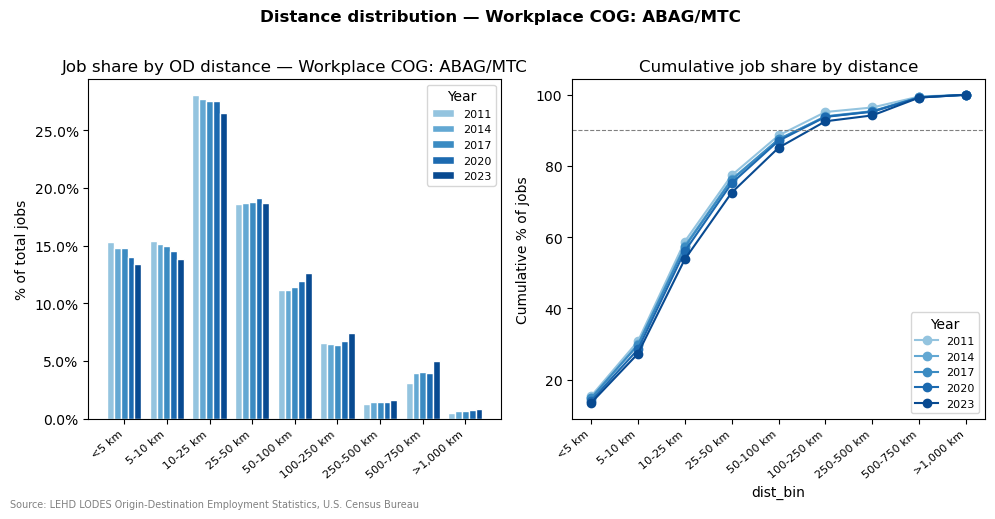

In [57]:
# Bay Area jobs 
plot_distance_overview(ods, w_cog=['ABAG/MTC'])


### Further checks on distance bands

In [58]:
COG_FOCUS  = ['ABAG/MTC', 'SACOG','SCAG','SANDAG']  # or None for all


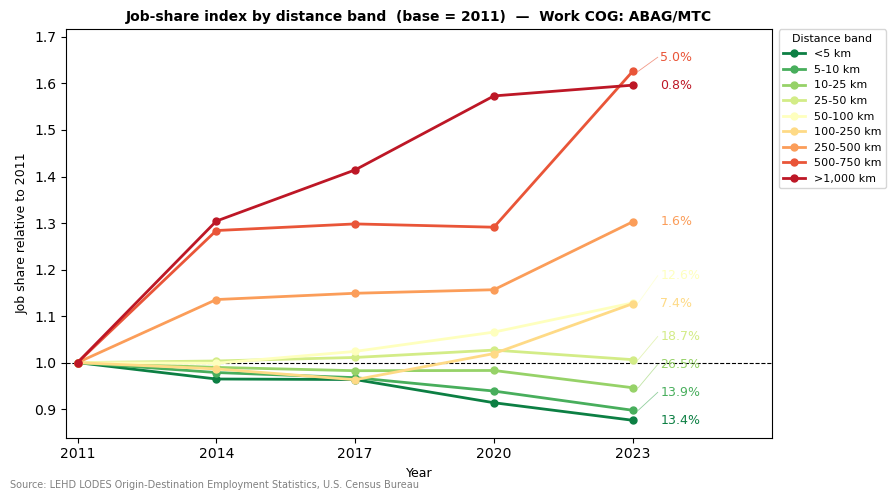

In [59]:

# Jobs by place of work in the Bay Area
# Kind of striking trend here for the longer bands - we didn't see that tail on the residence based tabulation at all.

plot_band_trend(ods, w_cog=['ABAG/MTC'])


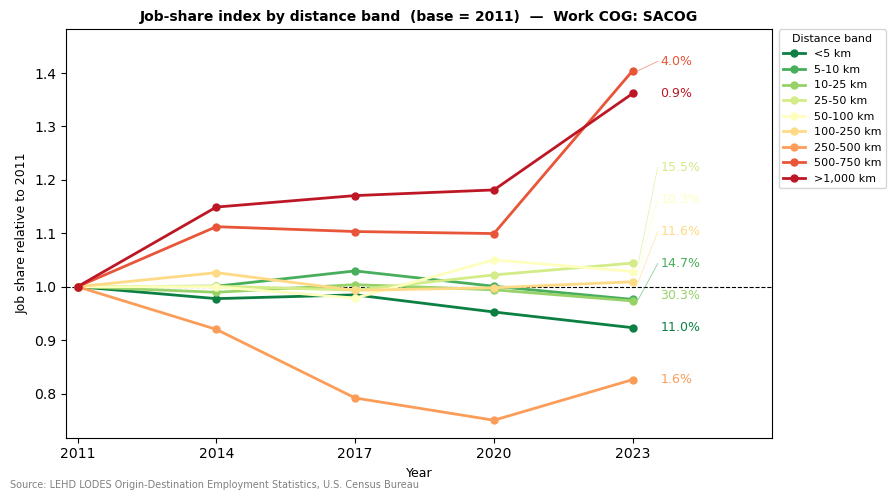

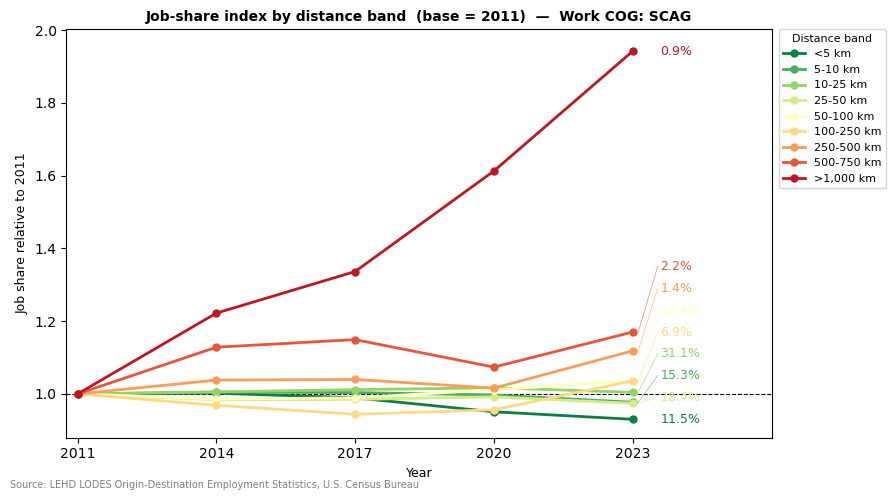

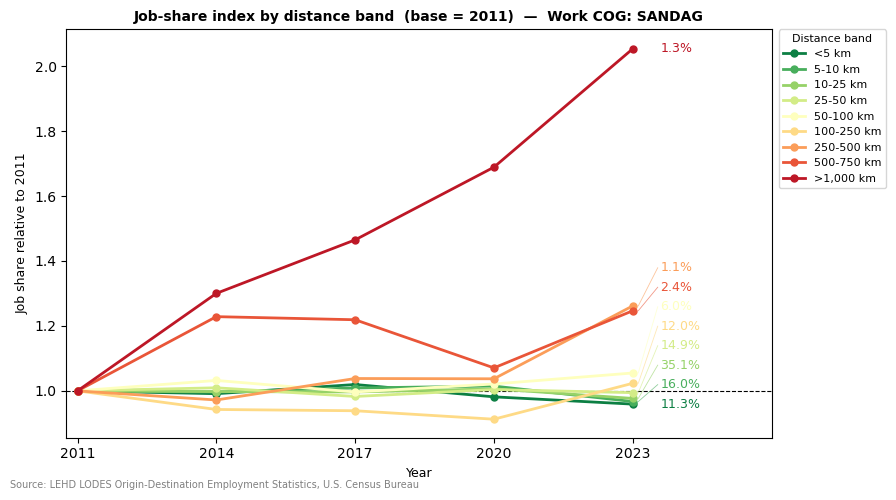

In [60]:

# Iterate work-COG for the remaining major COGs
for cog in COG_FOCUS[1:]:
    plot_band_trend(ods, w_cog=[cog])


### Check weighted mean "commute" distances over time - by workplace COG 

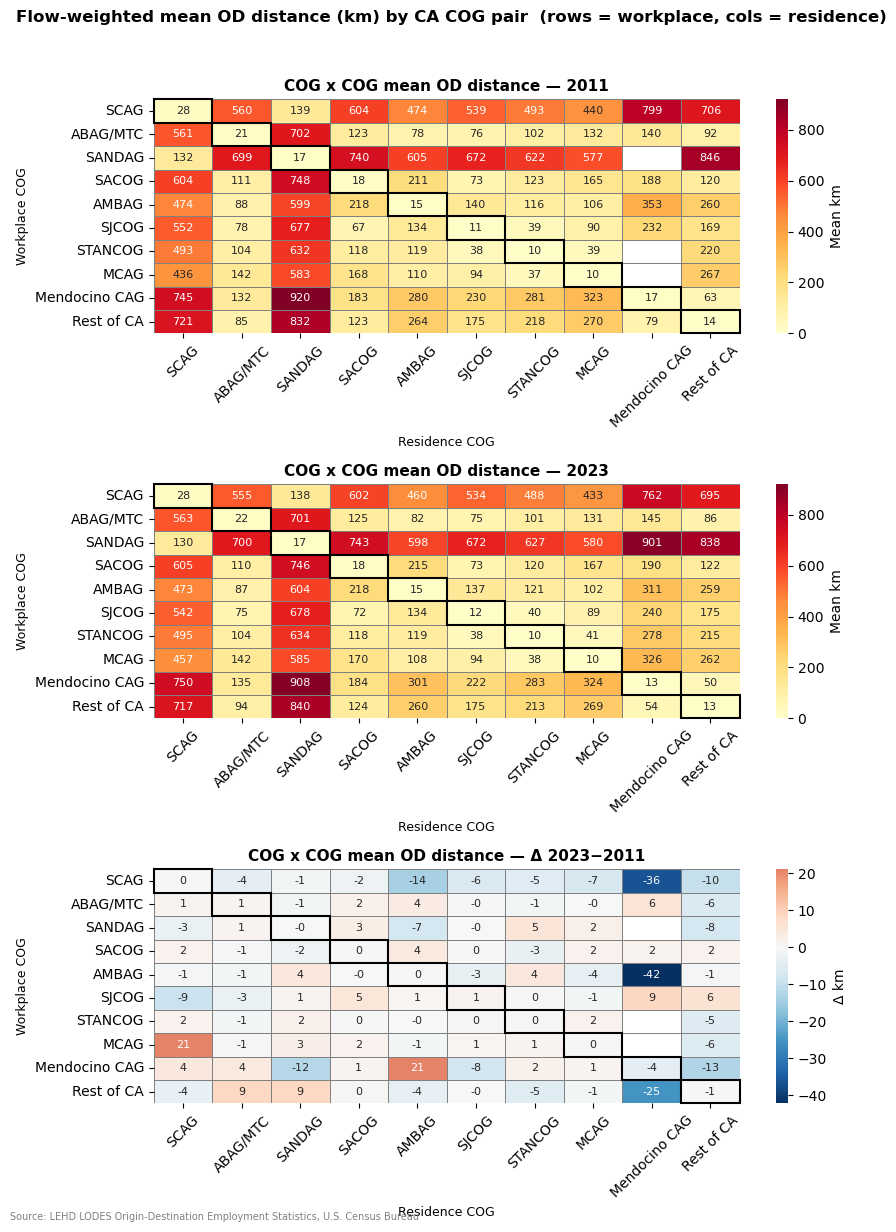

In [61]:
# COG x COG mean distance across years
# Rows = workplace COG (inbound commute shed), columns = residence COG.
# Ordered by total inbound jobs so the largest destination COGs appear first.

import seaborn as sns   # already loaded in prepare_ notebook; add here just in case

cog_year_tables = {}
for year in YEARS:
    cog_dist, _ = geo_stats[year]
    cog_year_tables[year] = (
        cog_dist
        .pivot(index='w_cog', columns='h_cog', values='mean_dist_km')
        .round(1)
    )

# Order by inbound (workplace) total jobs in the first year
first_cog, _ = geo_stats[YEARS[0]]
cog_order = (
    first_cog.groupby('w_cog')['total_jobs'].sum()
    .sort_values(ascending=False).index.tolist()
)

pd.options.display.float_format = '{:.1f}'.format
# print('Flow-weighted mean OD distance (km) — COG x COG  (rows = workplace, cols = residence)\n')
# for year in YEARS:
#     tbl = cog_year_tables[year].reindex(index=cog_order, columns=cog_order)
#     print(f'  {year} ')
#     print(tbl.to_string())
#     print()

# Change table: last vs first year
delta = (cog_year_tables[YEARS[-1]] - cog_year_tables[YEARS[0]]).reindex(
    index=cog_order, columns=cog_order
)
# print(f'  Δ {YEARS[-1]} minus {YEARS[0]} (km) ')
# print(delta.to_string())

# COG x COG heatmap — first year, last year, and Δ side by side 
import matplotlib.colors as mcolors

ca_cogs = [c for c in cog_order if c not in ('Other/Out-of-CA',)]

t_first = cog_year_tables[YEARS[0]].reindex(index=ca_cogs, columns=ca_cogs)
t_last  = cog_year_tables[YEARS[-1]].reindex(index=ca_cogs, columns=ca_cogs)
t_delta = (t_last - t_first)

vmax_dist = max(t_first.max().max(), t_last.max().max())

fig, axes = plt.subplots(3, 1, figsize=(9, 12))

for ax, mat, title, cmap, center, vmin, vmax in [
    (axes[0], t_first, f'{YEARS[0]}',         'YlOrRd', None, 0,        vmax_dist),
    (axes[1], t_last,  f'{YEARS[-1]}',         'YlOrRd', None, 0,        vmax_dist),
    (axes[2], t_delta, f'Δ {YEARS[-1]}−{YEARS[0]}', 'RdBu_r', 0, None, None),
]:
    kw = dict(annot=True, fmt='.0f', ax=ax, linewidths=0.4, linecolor='gray',
               annot_kws={'size': 8}, cbar=True)
    if center is not None:
        sns.heatmap(mat, cmap=cmap, center=center, **kw,
                    cbar_kws={'label': 'Δ km'})
    else:
        sns.heatmap(mat, cmap=cmap, vmin=vmin, vmax=vmax, **kw,
                    cbar_kws={'label': 'Mean km'})
    _highlight_diagonal(ax, len(ca_cogs))
    ax.set_title(f'COG x COG mean OD distance — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Residence COG', fontsize=9)
    ax.set_ylabel('Workplace COG', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Flow-weighted mean OD distance (km) by CA COG pair  (rows = workplace, cols = residence)', fontweight='bold', y=1.02)
plt.tight_layout()
_add_source(fig)
plt.show()


### Initial read
* There is an increase on the face of it of the longer distance OD relationship in relative terms, even if the absolute count remains small. 
* Mostly focusing on the diagonal, the COG specific OD is modest - by definition almost - as that would clip the longer tail.


### Further detail — within-COG county focus

**County × county mean-distance heatmaps** — same flow-weighted average OD distance metric as above, but drilled down to county pairs within each COG, shown for first and last year side by side.


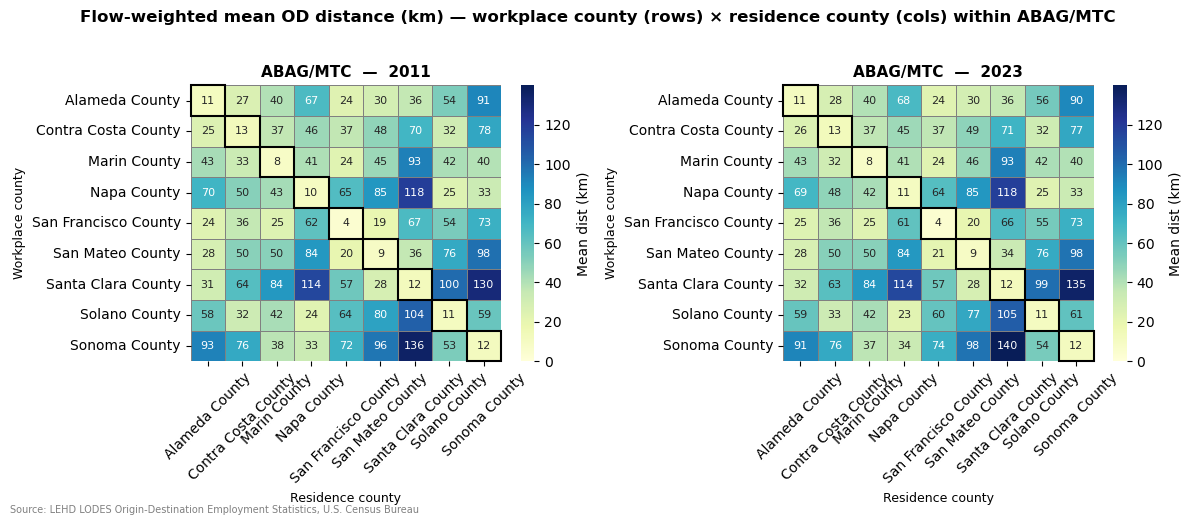

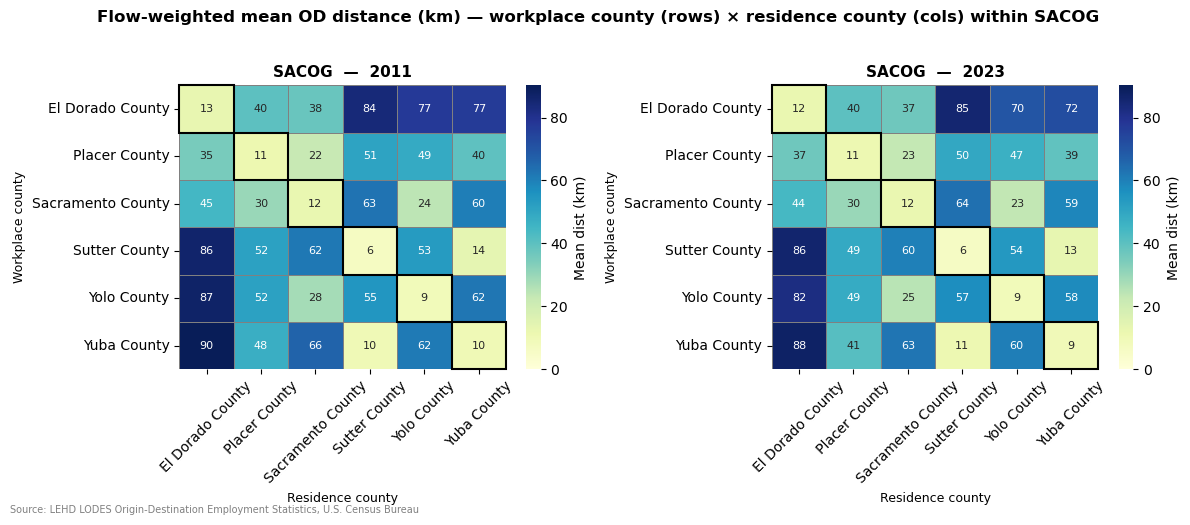

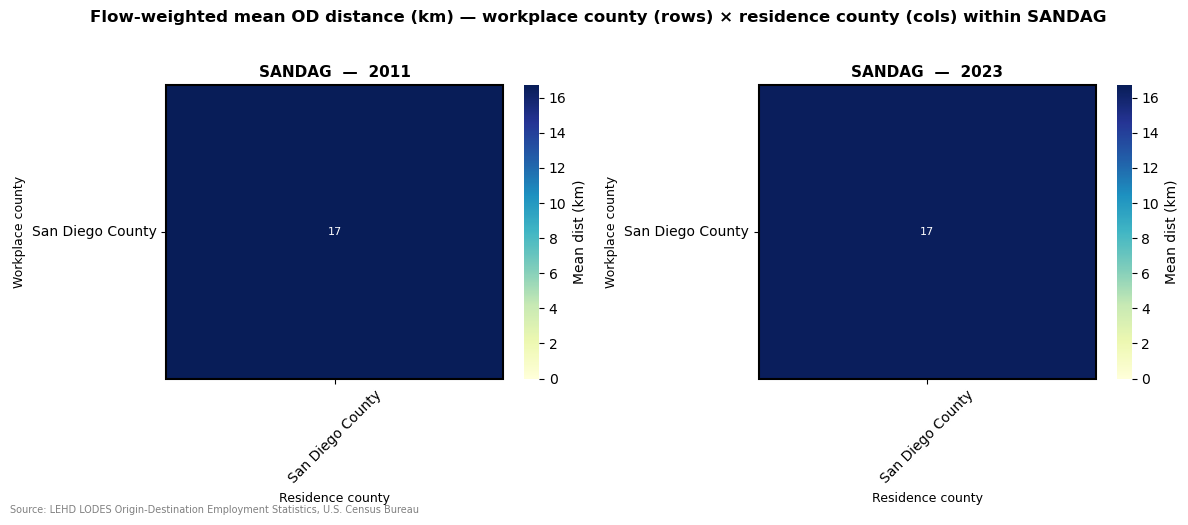

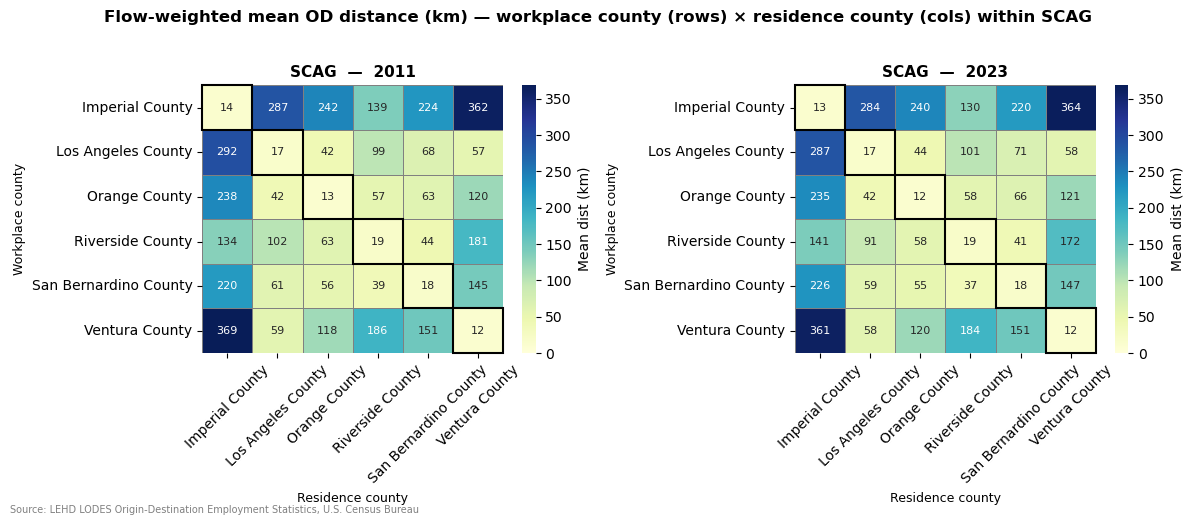

In [62]:
# County x County mean distance heatmaps — one grid per CA COG
# SHOW_YEARS: which years to overlay; COG_FOCUS filters to specific COGs (None = all CA COGs)
SHOW_YEARS = [YEARS[0], YEARS[-1]]   # first and last
COG_FOCUS  = ['ABAG/MTC', 'SACOG','SCAG','SANDAG']  #  or None for all

# Collect county_dist for requested years
county_tbls = {yr: geo_stats[yr][1] for yr in SHOW_YEARS}
all_cogs    = sorted(set(county_tbls[SHOW_YEARS[0]]['h_cog'].unique()))
if COG_FOCUS:
    all_cogs = [c for c in all_cogs if c in COG_FOCUS]

for cog in all_cogs:
    # Build one pivot per year, find union of counties
    pivots = {}
    for yr in SHOW_YEARS:
        sub = county_tbls[yr][county_tbls[yr]['h_cog'] == cog]
        if sub.empty:
            continue
        pivots[yr] = sub.pivot(index='w_county', columns='h_county', values='mean_dist_km')

    if not pivots:
        continue

    # Union county order sorted by name
    all_c = sorted(set().union(*[set(p.index) | set(p.columns) for p in pivots.values()]))
    n_yr   = len(pivots)

    fig, axes = plt.subplots(1, n_yr, figsize=(6 * n_yr, 5), squeeze=False)
    vmax_c = max(p.max().max() for p in pivots.values() if not p.empty)

    for ax, (yr, piv) in zip(axes[0], pivots.items()):
        mat = piv.reindex(index=all_c, columns=all_c).rename(
            index=_county_label, columns=_county_label
        )
        sns.heatmap(
            mat, annot=True, fmt='.0f', cmap='YlGnBu',
            vmin=0, vmax=vmax_c,
            cbar_kws={'label': 'Mean dist (km)'},
            ax=ax, linewidths=0.4, linecolor='gray',
            annot_kws={'size': 8}
        )
        _highlight_diagonal(ax, len(all_c))
        ax.set_title(f'{cog}  —  {yr}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Residence county', fontsize=9)
        ax.set_ylabel('Workplace county', fontsize=9)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    plt.suptitle(
        f'Flow-weighted mean OD distance (km) — workplace county (rows) × residence county (cols) within {cog}',
        fontweight='bold', y=1.02
    )
    plt.tight_layout()
    _add_source(fig)
    plt.show()


### OD scatter views
Two takes on the raw tract-pair distance distribution:
* A **hexbin** plot relating distance (x) to jobs per OD pair (y, log scale), where color counts the number of tract pairs in each bin. The log scale can visually amplify the secondary cluster around 500 km.
* A **regular scatter** with dot size ∝ log(jobs) — without the log y-scale, which makes the near-local mass visually dominant and the far-distance pairs more proportional to their actual weight.


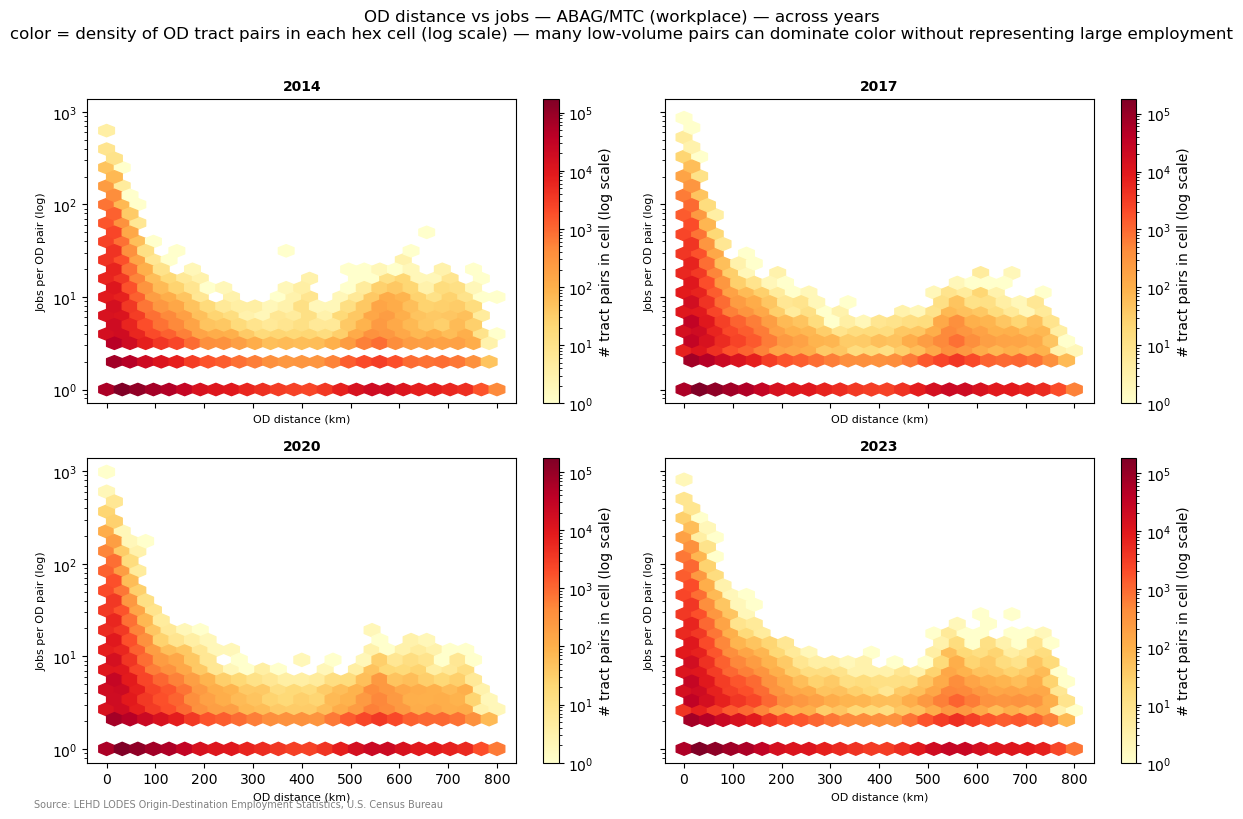

In [63]:
# filter to Bay Area workplace geo.
# geo_end='work' (default) facets on w_cog; pass geo_end='home' to switch to residence.

plot_od_scatter(
    years       = YEARS[1:],
    facet_by    = 'year',
    cog_focus   = ['ABAG/MTC'],
    dist_km_max = 800,
    geo_end     = 'work',
)


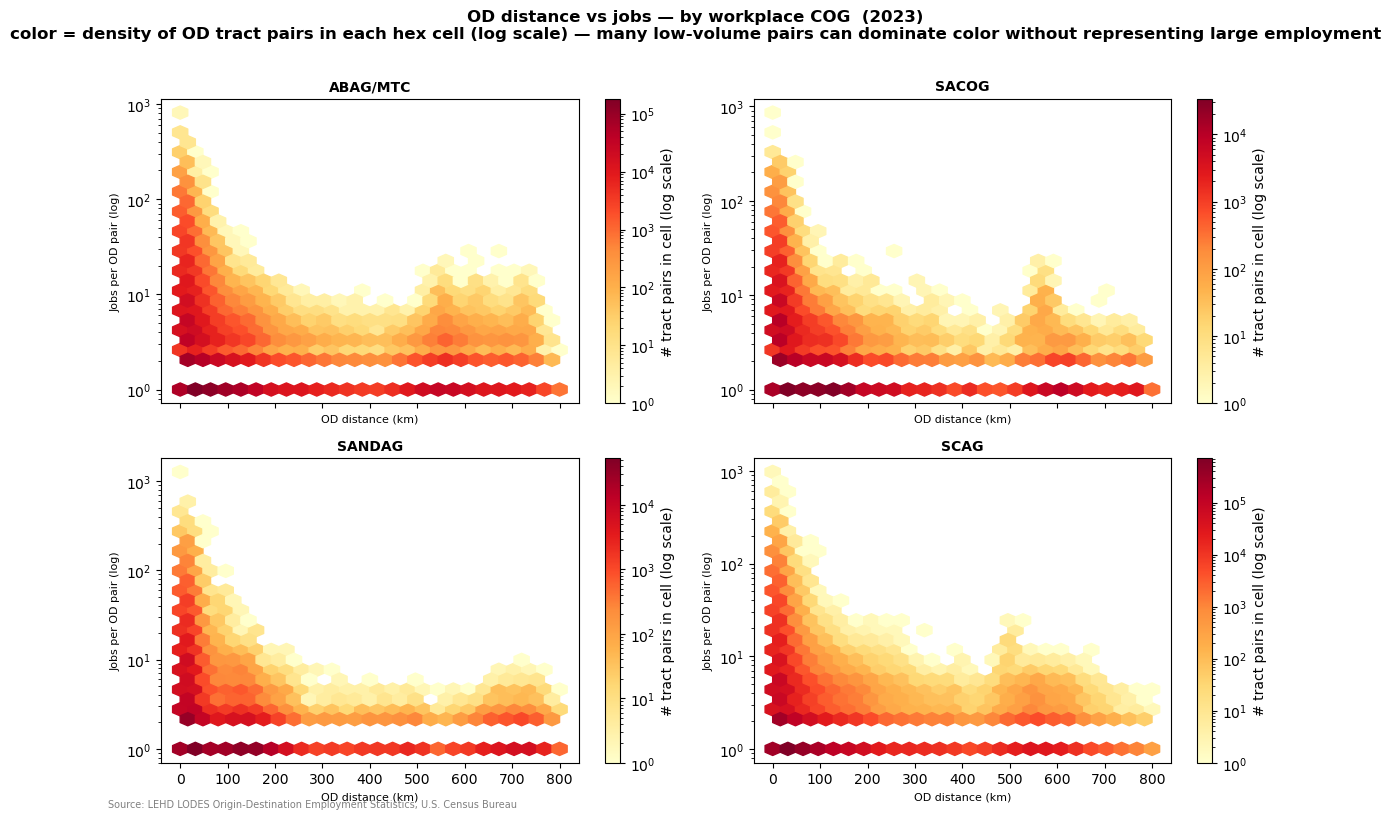

In [64]:
# COG scatter — hexbin - distance vs jobs, one panel per workplace COG.

plot_od_scatter(
    years      = YEARS[-1],                               # single year; use YEARS for all
    facet_by   = 'cog',
    cog_focus  = ['ABAG/MTC', 'SACOG', 'SANDAG', 'SCAG'],  # None = all CA COGs
    dist_km_max = 800,
    geo_end    = 'work',
)


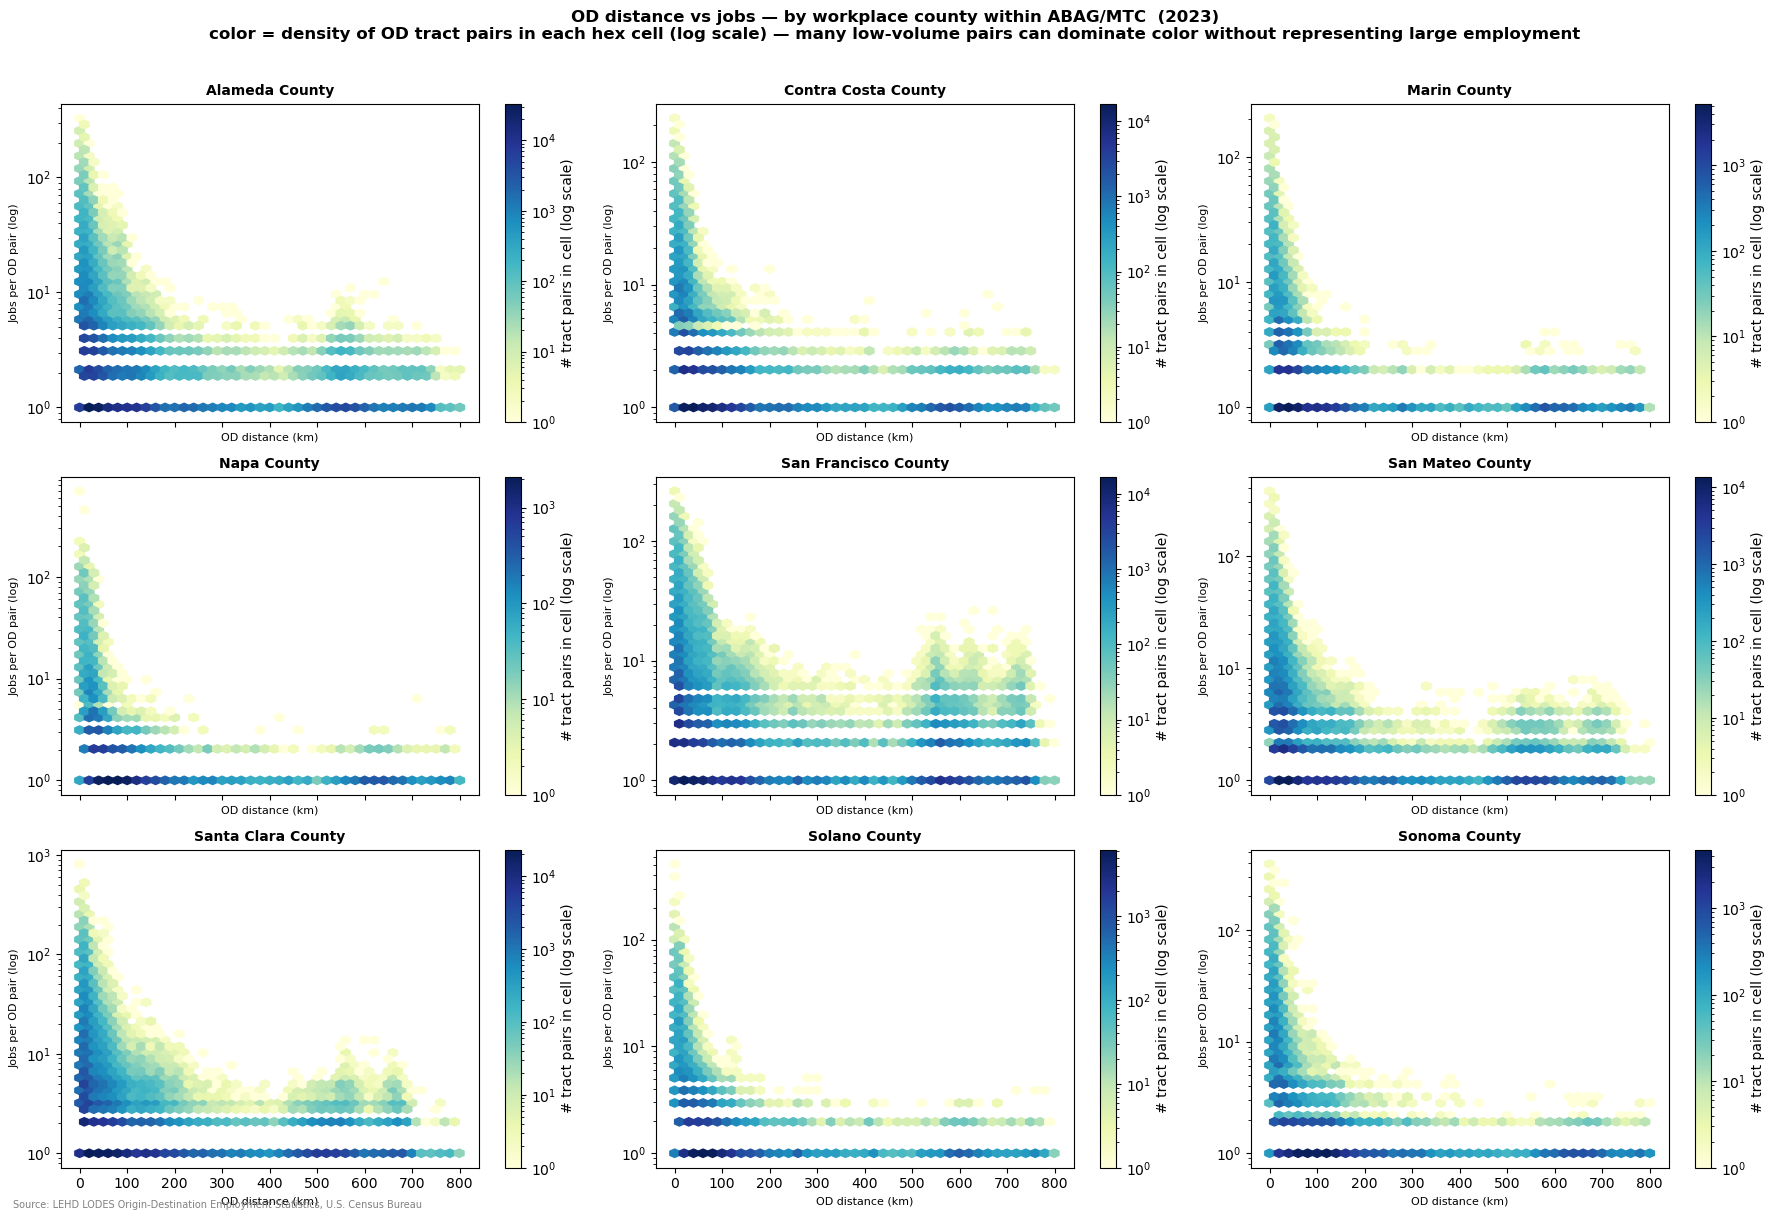

In [65]:
# County scatter — one panel per workplace county within a single COG.

plot_od_scatter(
    years      = YEARS[-1],       # single year; use YEARS for all
    facet_by   = 'county',
    county_cog = 'ABAG/MTC',
    dist_km_max = 800,
    geo_end    = 'work',
)


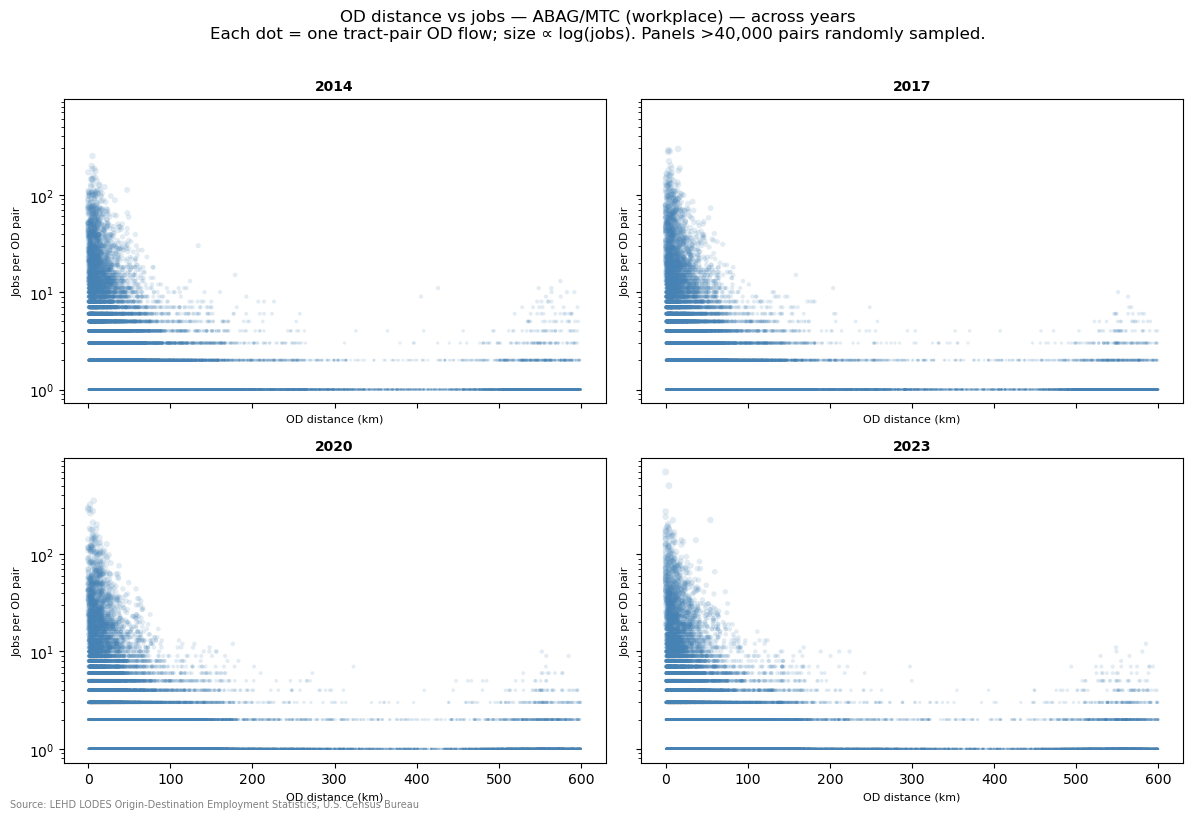

In [66]:
# scatter mode. These are not actually that useful

plot_od_scatter(
    years       = YEARS[1:],
    facet_by    = 'year',
    cog_focus   = ['ABAG/MTC'],
    dist_km_max = 600,
    geo_end     = 'work',
    kind        = 'scatter',
    alpha       = 0.15,   
)


## Are jobs becoming more concentrated in fewer workplace tracts over time?

The distance-band trend in Section 1 shows longer-distance flows growing at the margins. Before drilling into the specific geographic peak at ~500 km, it is worth asking a broader structural question: is the *overall* distribution of employment across workplace tracts becoming more unequal over time? If the Bay Area job market were agglomerating into fewer, denser nodes — expanding campuses, transit-adjacent towers, industrial parks — we would expect to see that in these metrics independently of any coding artifact. Conversely, stable concentration metrics would suggest that whatever is driving the marginal growth in long-distance flows is not reshaping the fundamental employment geography.

Three views below:

- **Top-N% share trend** — the fraction of total jobs in the top 10 / 25 / 50 percent of workplace tracts, year over year. Rising shares = increasing concentration.
- **Lorenz curve** — first vs last year; the further the curve bows above the equality diagonal, the more lopsided the distribution.
- **Gini, HHI, and NSE** — in the summary table. Gini: 0 = perfectly equal, 1 = all jobs in one tract. HHI near 0 = dispersed, near 1 = monopoly. NSE (Normalized Shannon Entropy): 0 = all jobs in one tract, 1 = perfectly even across all tracts.

`w_cog=None` uses all CA workplaces as the universe.


Workplace job concentration — Workplace COG: ABAG/MTC

      n_tracts  total_jobs  top10pct  top25pct  top50pct   gini    hhi    nse
year                                                                         
2011      1764     3236259   55.5749   76.3855   90.7172 0.6697 0.0036 0.8698
2014      1764     3564662   56.6356   76.2838   90.3713 0.6695 0.0039 0.8665
2017      1764     3908569   57.4521   76.8494   90.5593 0.6756 0.0039 0.8635
2020      1765     3784669   58.8652   77.9270   90.9684 0.6868 0.0042 0.8564
2023      1764     4052961   57.9123   76.9857   90.3853 0.6762 0.0041 0.8609



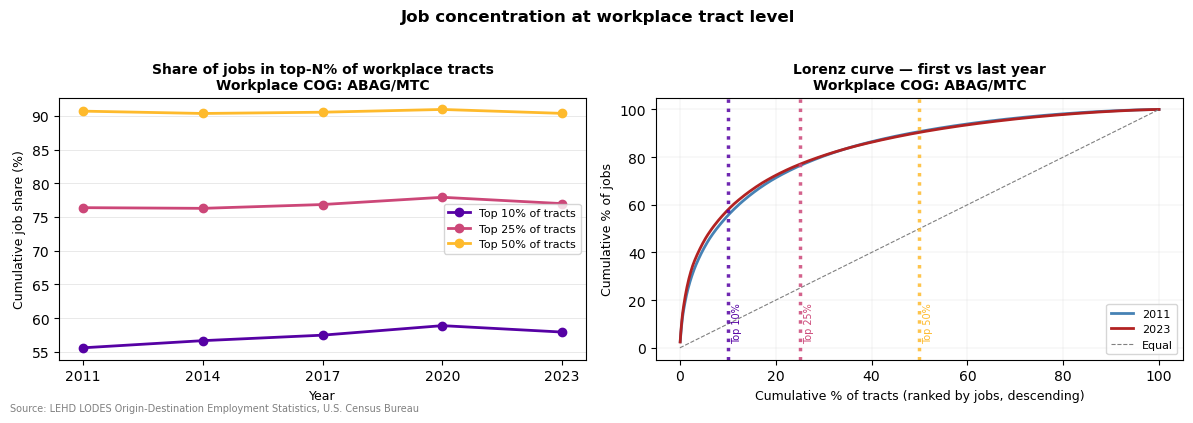

In [67]:
# All CA workplaces — pass w_cog='ABAG/MTC' (or any COG) to restrict
plot_job_concentration(ods, w_cog='ABAG/MTC')


## What explains the far-band cluster at ~500 km?

The secondary cluster of OD pairs at 500–600 km is too far for any plausible daily commute, and its geographic signature already points toward an explanation: 550 km corresponds almost exactly to the Bay Area ↔ Southern California gap (SCAG ~550–600 km; SANDAG ~700 km). Tellingly, SANDAG's far-band peak points toward the Bay Area rather than toward Los Angeles (~180 km away) — a pattern that is hard to reconcile with genuine commuting.

Two questions let us test the coding-artifact hypothesis more formally:

1. **Is the signal stable or growing?** A background coding artifact should be roughly flat year to year. Steady growth across the full series would point instead toward a genuine structural shift in job-worker geography.
2. **Do far-band flows cluster at a handful of destination tracts?** Genuine long-distance commuting disperses across many workplaces; a HQ-address artifact lands on the few tracts hosting major corporate campuses.

| Diagnostic | HQ-coding artifact | Genuine long-distance commuting |
|---|---|---|
| Year-over-year change | Roughly stable | Steady growth over time |
| Top destination tracts | Few `w_tracts` capture most far-band jobs | Far-band jobs spread across many `w_tracts` |


Job counts by distance band across years (workplace COG = ABAG/MTC )

      near_jobs  far_jobs  far_pct    total
year                                       
2011    3083528    130766        4  3236259
2014    3354853    185286        5  3564662
2017    3674239    208087        5  3908569
2020    3555803    202799        5  3784669
2023    3760092    261906        6  4052961

Far-band residence COG distribution  (2023) 

          h_cog   S000  pct
           SCAG 175239   67
Other/Out-of-CA  44959   17
         SANDAG  41708   16

Top 20 destination tracts in far band  (2023, w_cog='ABAG/MTC') 
   (high concentration → HQ-coding artifact; flat → spread-out workplaces)

    w_tract             w_county  jobs  h_tracts  cum_pct
06075011700 San Francisco County 17726      6055        7
06075061501 San Francisco County  8730      4415       10
06001441503       Alameda County  5568      3227       12
06085505006   Santa Clara County  5086      3367       14
06075061507 San Francisco Count

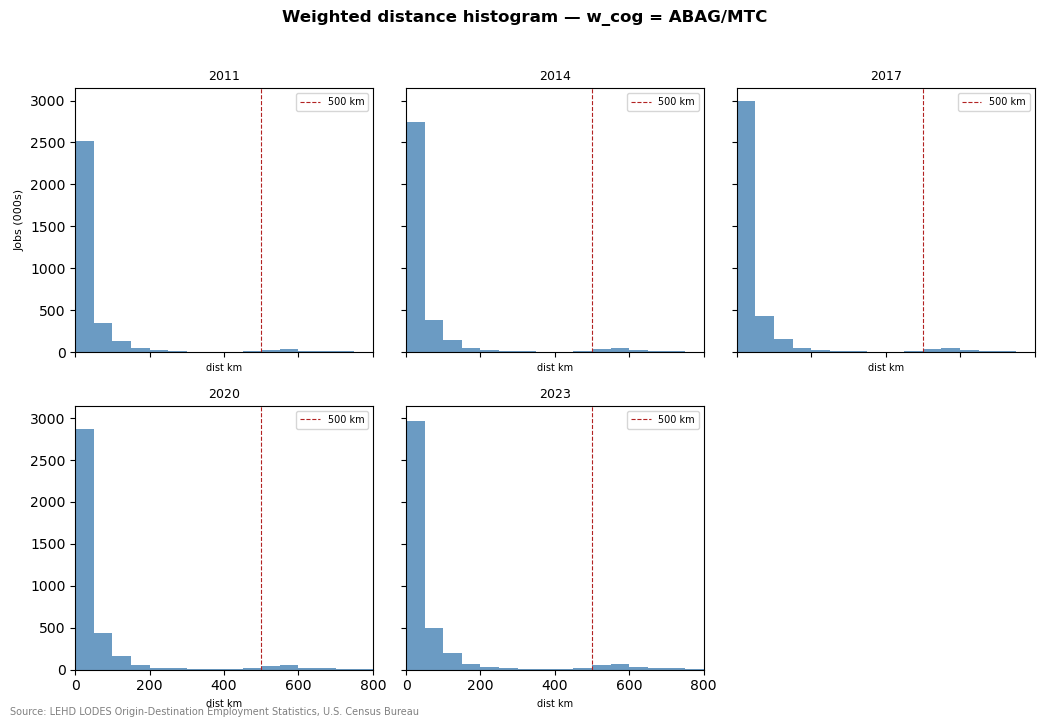

In [68]:
# Far-band diagnostics — oriented to the WORKPLACE end
# Tune these to probe different COGs / distance cuts
DIAG_COG      = 'ABAG/MTC'   # workplace COG to examine
NEAR_MAX      =  250          # km — upper bound of "near" band
FAR_MIN       =  350          # km — lower bound of "far" band

pd.options.display.float_format = '{:,.0f}'.format

# 1. Year-over-year job counts in each band (jobs arriving at DIAG_COG workplaces)
print('Job counts by distance band across years (workplace COG =', DIAG_COG, ')\n')
rows = []
for yr in YEARS:
    od = ods[yr][ods[yr]['w_cog'] == DIAG_COG].copy()
    near_jobs = od.loc[od['dist_km'] <= NEAR_MAX, 'S000'].sum()
    far_jobs  = od.loc[od['dist_km'] >= FAR_MIN,  'S000'].sum()
    total     = od['S000'].sum()
    rows.append({'year': yr, 'near_jobs': near_jobs, 'far_jobs': far_jobs,
                 'far_pct': far_jobs / total * 100, 'total': total})

band_tbl = pd.DataFrame(rows).set_index('year')
print(band_tbl.to_string())

# 2. Residence COG distribution in the far band — where do the long-distance workers come FROM?
yr_ref = YEARS[-1]
od_far = ods[yr_ref][(ods[yr_ref]['w_cog'] == DIAG_COG) &
                      (ods[yr_ref]['dist_km'] >= FAR_MIN)].copy()

print(f'\nFar-band residence COG distribution  ({yr_ref}) \n')
rcog = (od_far.groupby('h_cog')['S000'].sum()
        .sort_values(ascending=False)
        .reset_index())
rcog['pct'] = rcog['S000'] / rcog['S000'].sum() * 100
print(rcog.to_string(index=False))

# 3. HQ-concentration check: top workplace tracts receiving far-band workers
print(f'\nTop 20 destination tracts in far band  ({yr_ref}, w_cog={DIAG_COG!r}) ')
print('   (high concentration → HQ-coding artifact; flat → spread-out workplaces)\n')
top_w = (od_far.groupby('w_tract')
         .agg(jobs=('S000', 'sum'), h_tracts=('h_tract', 'nunique'))
         .sort_values('jobs', ascending=False)
         .head(20)
         .reset_index())
top_w['w_county'] = top_w['w_tract'].str[:5].map(ca_county_fips_map).fillna(top_w['w_tract'].str[:5])
top_w['cum_pct']  = top_w['jobs'].cumsum() / od_far['S000'].sum() * 100
print(top_w[['w_tract', 'w_county', 'jobs', 'h_tracts', 'cum_pct']].to_string(index=False))

# 4. Distance histogram — workers arriving at DIAG_COG workplaces
nrows, ncols = _grid_shape(len(YEARS))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows),
                         sharey=True, sharex=True, squeeze=False)
axes_flat = axes.flatten()

for ax, yr in zip(axes_flat, YEARS):
    dat = ods[yr][(ods[yr]['w_cog'] == DIAG_COG) & (ods[yr]['S000'] > 0)]
    ax.hist(dat['dist_km'], bins=range(0,801,50), weights=dat['S000'] / 1e3,
            color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(500, color='firebrick', lw=0.8, linestyle='--', label='500 km')
    ax.set_xlim(0, 800)
    ax.set_title(str(yr), fontsize=9)
    ax.set_xlabel('dist km', fontsize=7)
    ax.legend(fontsize=7)

for ax in axes_flat[len(YEARS):]:
    ax.set_visible(False)

axes_flat[0].set_ylabel('Jobs (000s)', fontsize=8)
fig.suptitle(f'Weighted distance histogram — w_cog = {DIAG_COG}', fontweight='bold', y=1.02)
plt.tight_layout()
_add_source(fig)
plt.show()


## Does far-band growth vary by industry segment?

The industry-segment split is the sharpest single test of the HQ-coding hypothesis. LODES classifies every job into one of three broad sectors drawn directly from NAICS:

| Segment | Coverage | HQ-coding risk |
|---|---|---|
| **SI01** Goods-producing | Agriculture, mining, construction, manufacturing | **Low** — these jobs are physically tied to a site (a factory floor, a field, a building site). A worker assigned to a tract that is 600 km from their home almost certainly reflects a coding error or a genuine mismatch, not a real commute. |
| **SI02** Trade & Transport | Wholesale/retail trade, transportation, warehousing, utilities | **Medium** — distribution centres and logistics hubs are real fixed locations, but corporate staff at large retail chains may be coded to HQ. |
| **SI03** Other Services | Information, finance, professional/scientific, management, admin, healthcare, arts, food | **High** — this is where tech, finance, and multi-establishment professional firms live. HQ-coding is most credible here. |

If the far-band rise is confined to SI03 while SI01 stays flat or declines, the story is HQ-coding in knowledge-economy firms, not a broad structural shift in commuting. If all three segments show proportional far-band growth, the signal is more likely genuine (or a systematic census processing artifact affecting all sectors equally).

Each panel below is the same indexed band-trend chart as Section 1, but restricted to a single segment. Y-axes are shared across panels so magnitudes are directly comparable.


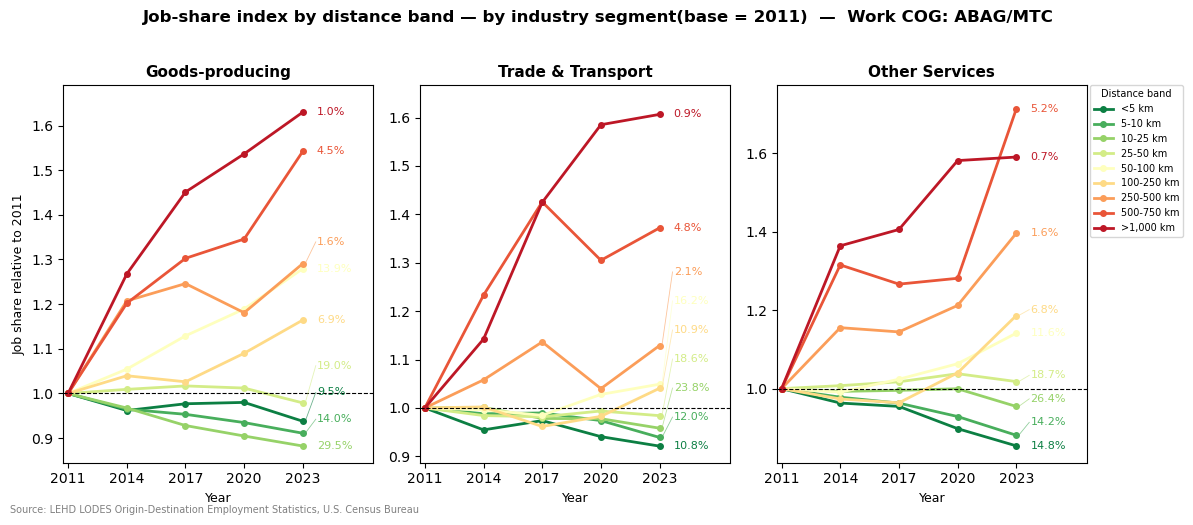

In [69]:
plot_band_trend_seg(ods, w_cog=['ABAG/MTC'],sharey=False)

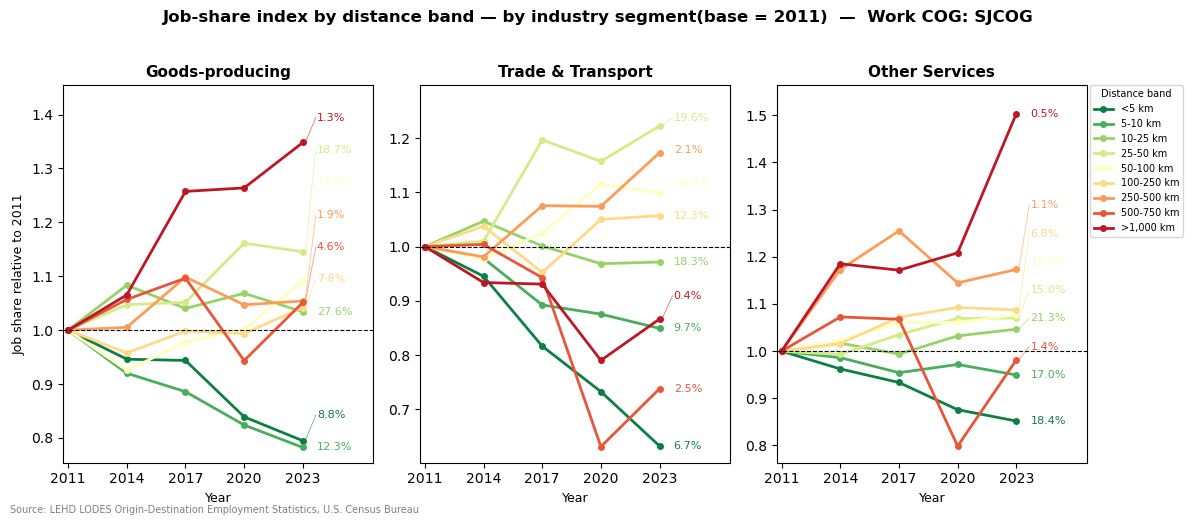

In [70]:
# This is the segmented industry distance bands, for the core COGs 
plot_band_trend_seg(ods, w_cog=['SJCOG'],sharey=False)


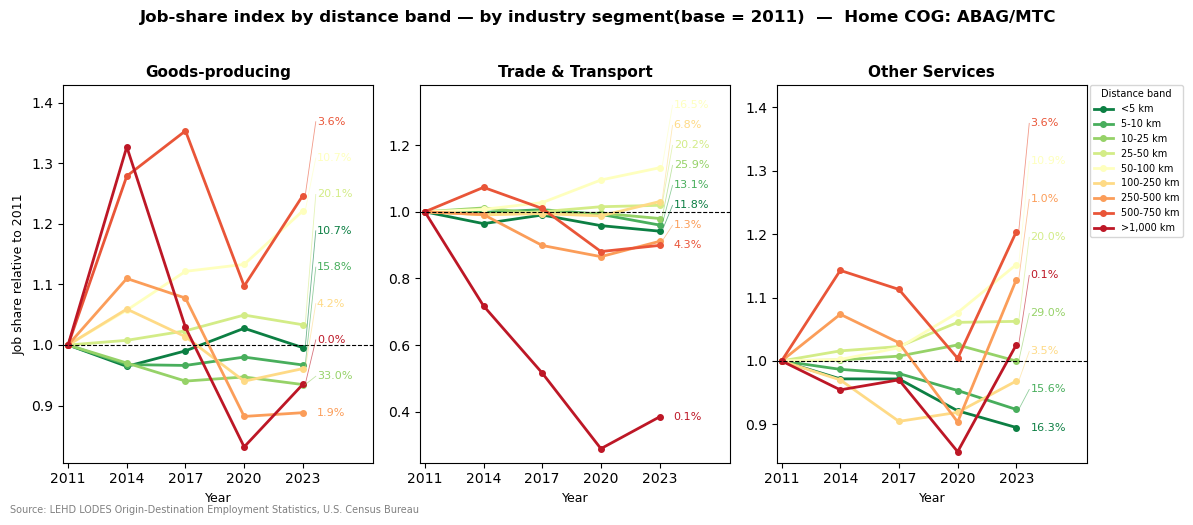

In [71]:
# This is the segmented industry distance bands, for the core COGs 
plot_band_trend_seg(ods, h_cog=['ABAG/MTC'],sharey=False)

### What the evidence taken together suggests

Three independent diagnostics mostly converge on the same answer.

**1. The far-band signal is growing, not stable.** A background HQ-coding artifact should produce a flat, year-invariant count of anomalous OD pairs. Instead, far-band job counts at Bay Area workplaces rise steadily from 2011 to 2023. Growth distinguishes a structural shift from a fixed administrative quirk.

**2. No corresponding tightening of destination-tract concentration.** If more workers were being assigned to a small set of corporate headquarters, Gini, HHI, and NSE would tighten over time as jobs funnelled into fewer tracts. They do not — the distribution across Bay Area workplace tracts is essentially unchanged across the period.

**3. Far-band growth is broad-based across all three industry segments.** The sharpest prediction of the HQ-coding hypothesis is that growth would be *sector-specific*: large in SI03 (Other Services — tech, finance, professional services, where multi-establishment HQ assignment is plausible) and flat in SI01 (Goods-producing, where jobs are physically tied to a site). Instead, all three segments show far-band growth. SI03 does show the strongest index rise in the 500–750 km band, but Goods-producing and Trade & Transport move in the same direction — a pattern that cannot be explained by knowledge-economy HQ coding alone.

Together, these findings are difficult to reconcile with HQ-address coding as at least the *primary* driver. The more consistent interpretation is a real and broad-based increase in out-of-region employment relationships — workers whose formal LODES workplace is in the Bay Area but whose residence has shifted to Southern California, the Central Valley, or beyond, and whose numbers have grown across the full range of industries over this period. Though - as noted - the scale remains modest, but this is somethign to watch.
